# Résiliation client SaaS (churn)

## 1. Informations

Certification : Aelion - Concervoir et implémenter une solution d'IA.  
Candidat : Aurélien Vallet  
Date de remise : 02/10/2026  
Version du notebook : 1

## 2. Présentation du sujet

### 2.1 Présentation globale

Le projet "churn" à pour contexte un éditeur de logiciel SaaS qui commercialise ses solutions via un système d'abonnement. La résilisation des abonnements par les client est donc la problématique principale de ce sujet car elle a un impacte directement sur la rentabilité de l'éditeur.

Un extrait de la base de donnée client nous est fournit au format csv (le fichier est présent dans `/docs/churn_saas_complet.csv` et `catalogue_plans.csv`) contenant respectivement l'ensemble des clients et les données des abonnements.

### 2.2 Besoin métier

En tant que développeur de solution Machine Learning capable, mon rôle est de répondre aux besoins du client en lui proposant une solution capable de lui faire obtenir de la plus values sur son business, ces outils sont à destinations des Customer Success Manager (CSM).

Ma solution Machine Learning devra permettre au CSM de :
- détecter les clients susceptibles de résilier leur abonnements à un instant T
- estimer ce qu'un client devrait lui rapporter au cours de sa vie client

Les métriques suivantes déterminerons si la solutions IA est efficaces :
- Taux de churn : clients ayant résiliés / clients total, nous utiliserons le taux de churn actuel (28%) comme celui de référence, l'objectif est de rester sous ce chiffre.
- Nombre de client sauvés : nombre de client qui souhaités résilier leur abonnement mais ont changés d'avis
- Ecart estimation CLV - CLV a un instant , le client est en mesure de savoir si le potentiel commercial d'un client est atteint ou non.

###  2.3 FN VS FP

Faux positifs = le modèle prédit une resiliation alors que le client ne prévoit pas de résilier (fausse alerte)
Faux négatifs = le modèle prédit une non-résiliation alors que le client prévoit de résilier (résiliation manquée)

Les faux positifs sont moins grave que les faux négatifs car ils impliquent principalement du temps d'investigation de la part du CSM et un dérangement du client, alors que les faux négatifs impliquent une perte de chiffre d'affaire immédiate.

### 2.4 Production IA

L'apprentissage supervisé sera priviligié dans notre cas car la donnée de "churn" est présente dans les données client.
Deux modèles de Machine Learning seront produit et livrés à l'équipe CSM :
- Modèle de prédiction du churn client
- Modèle d'estimation de CLV

Ces deux modèles seront intégrés dans un interface graphique afin de permettre aux CSM d'intérroger les modèles.

### 2.5 Hypothèses

La resiliation d'un client est selon moi causée par l'ensemble de ces critères :
- satisfaction client
    - support de qualité (peu de demande et traitement rapide) : `tickets_support_90j`,`delai_reponse_support_h` 
    - les services offert sont utilisés et il y a une part importante d'utilisateur actif (correspond à la demande de l'utilisateur) : `fonctionnalites_utilisees`,`taux_adoption_pct` 
    - appreciation du produit : `csat`
- Facteur économique
    - grosse entreprise : les grosses entreprises ont de moyens qui leurs permettent d'acheter des licences et ne pas se soucier du retour sur investissement `taille_entreprise` 
    - le retard de paiement indique que le client à des problèmes pour payer et il envisage surement la résiliation pour alléger ses dépenses : `retards_paiement_12m` 

### 2.6 Enjeux éthique

Impact écologique : les temps de traitement et les coûts écologiques (CO2 émis et électricité consommé) liés à l'entrainement des modèles sont presque négligeable dans notre cas étant donnée la rapidité avec laquelle ceux-ci sont réalisés.

Risque d'érreur : les modèles développés ne sont pas des solutions 100% fiable, il à une marge d'érreur qui peut induire des résultat faux, pour estimer ce pourcentage il faut se rapporter aux différents indicateurs présents dans chaque modèle (Recall, FP, FN).

Données sensibles : la solution IA ne traite aucune données à caractère personnelles, le RGPD ne n'applique pas.

### 2.7 Difficultés

Ce sujet présente certaines difficultés :
- Aucun contact avec le client, le sujet est statique il faut donc supputer certains données et prendre certaines décisions à la place du client.

## 3. 🥉🥈🥇 Ingestion complète

Lance les trois couches à la suite : `docs/*.csv` → 🥉 bronze → 🥈 silver →
🥇 gold. Chaque couche est intégralement rechargée, l'exécution est donc
rejouable sans créer de doublons.

In [ ]:
from ml_churn.ingestion.scripts.ingest_all import ingest_all

lignes_ingestion = ingest_all()

## 4. Exploration des données brutes

Deux types de graphiques construits sur la couche bronze, où les données brutes
sont stockées telles quelles : l'ingestion bronze doit donc avoir tourné. Les
valeurs sont normalisées à la volée — les données mélangent les casses
(`TPE`, `tpe`, `" TPE "`) et les unités (`20.0%`, `3.1 h`, `280.62 €`).

On distingue deux types de graphiques :

**Histogrammes** — ils nous permettent de voir le type de distribution d'un type de donnée, répartition des clients par secteur, pays, taille d'entreprise et plan, puis distribution des variables d'usage (ancienneté,
CSAT, délai de réponse du support, revenu mensuel…).

**Boîtes à moustaches** — ce graphique nous permet de visualiser les outliers dans une distribution, le boxplot isole individuellement chaque point au-delà de 1,5 × IQR.

Cette première analyse exploration des données nous sera utile lors de l'imputation de la couche silver pour déterminer certains choix de criètre d'imputation (moyenne, médiane...).

Les PNG sont exportés dans `src/visualization/graphs/<type>/<préfixe>_<donnée>.png`.

graphs/ vide : 44 graphiques supprimes

HISTOGRAMMES
bronze.churn_saas_complet_bronze : 5035 lignes lues


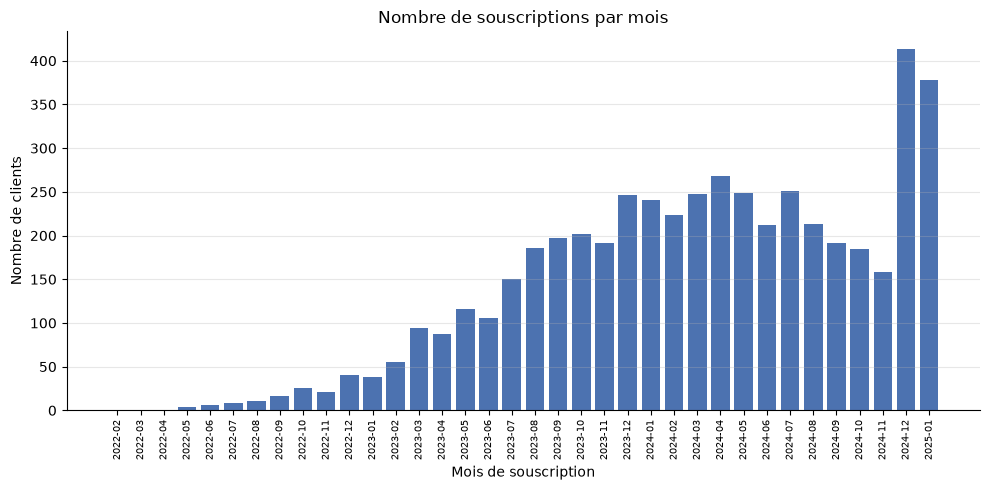

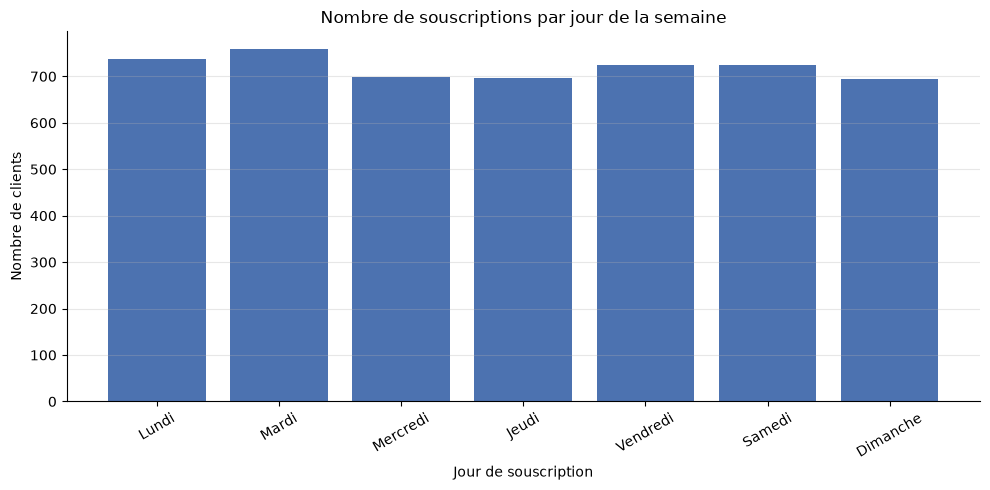

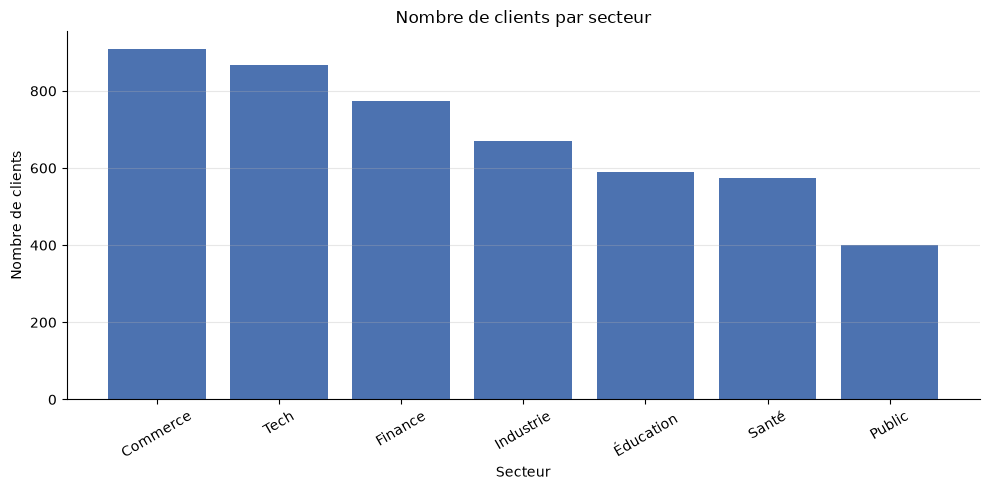

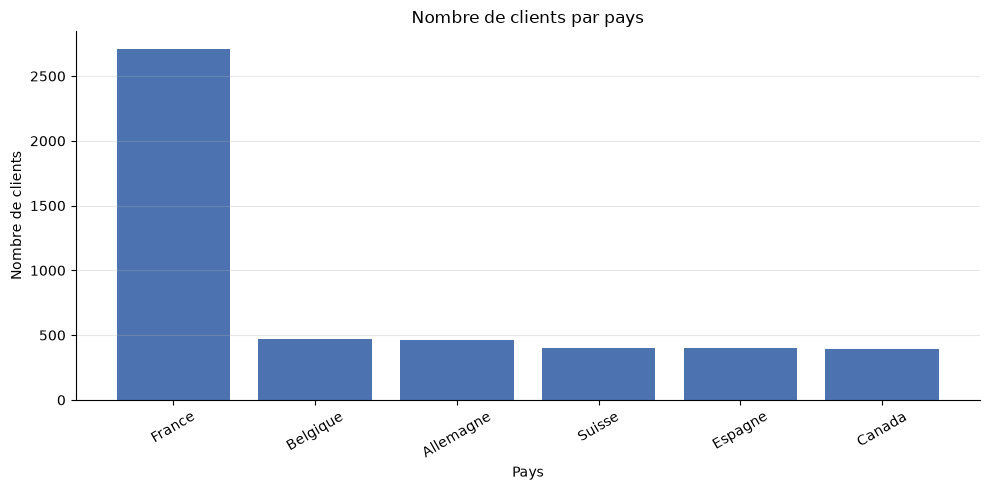

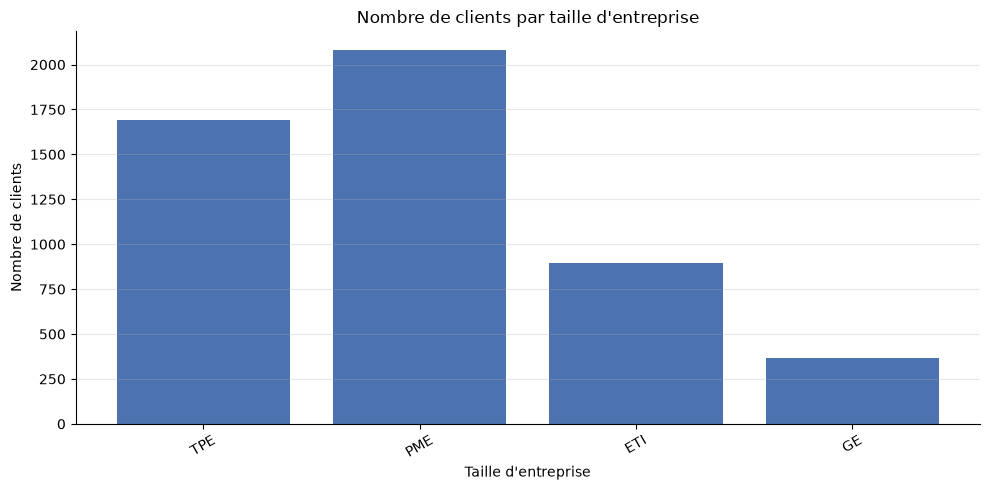

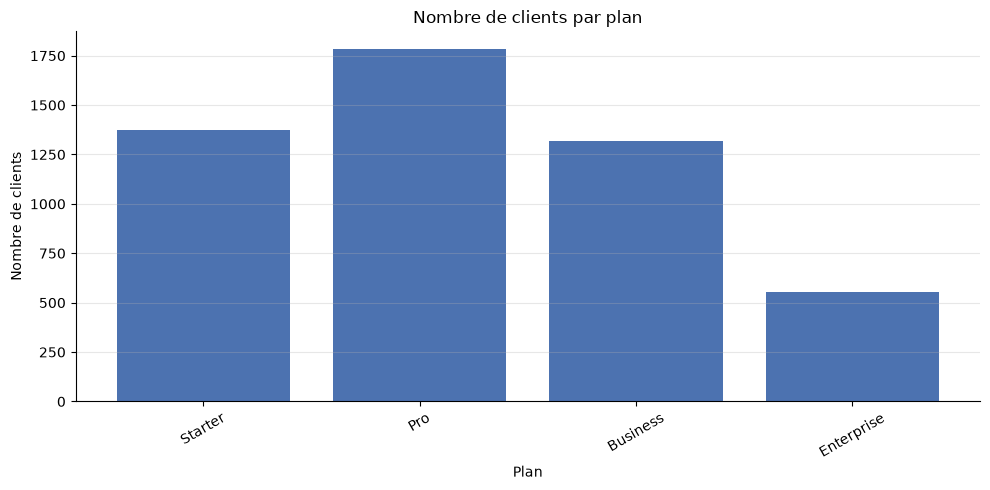

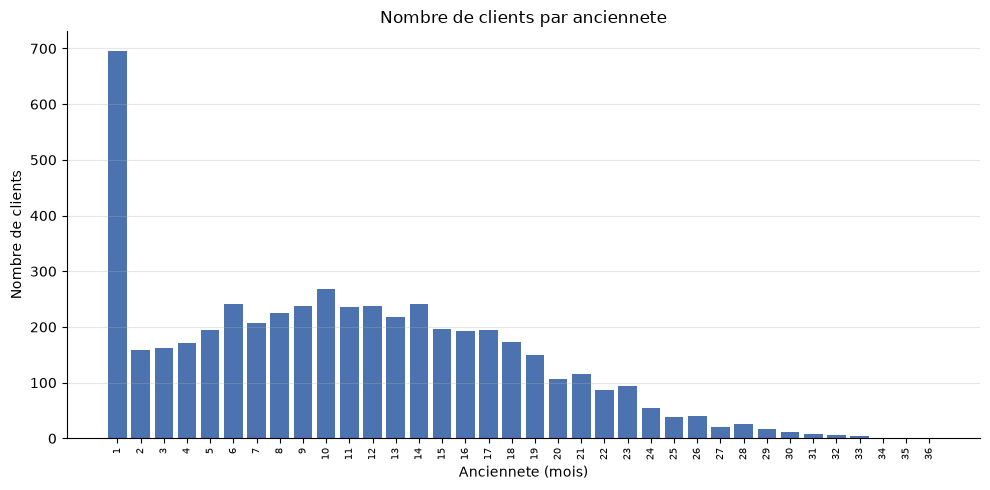

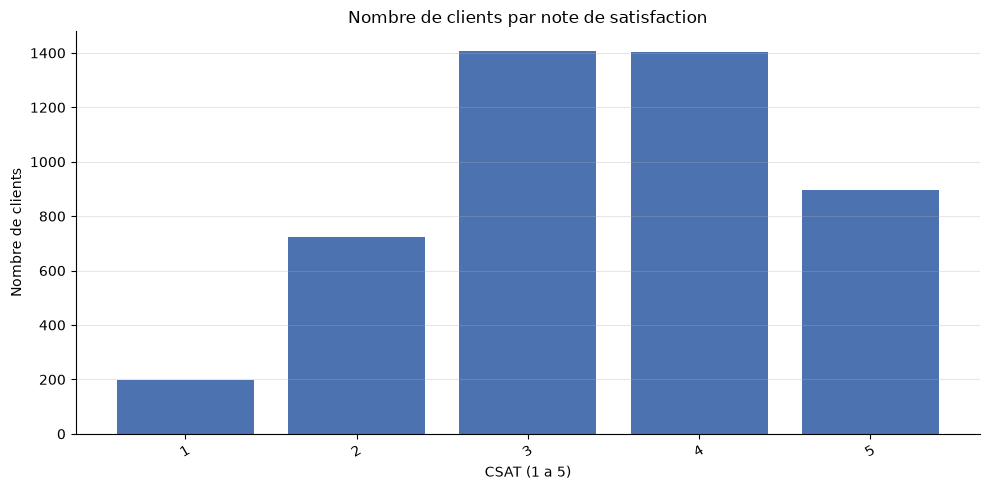

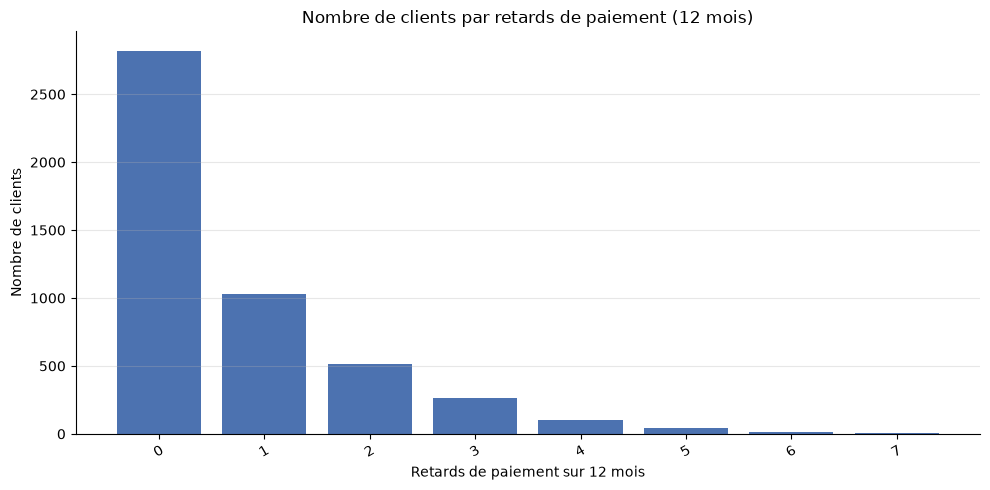

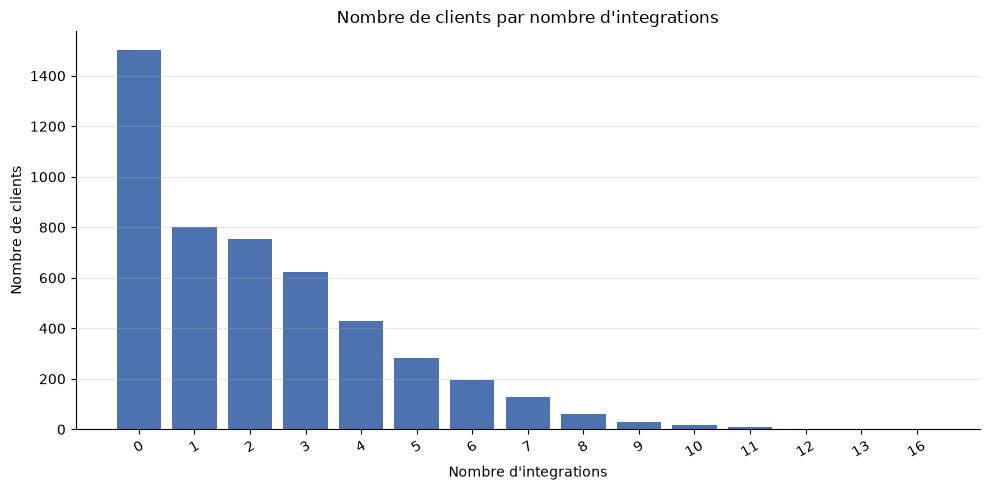

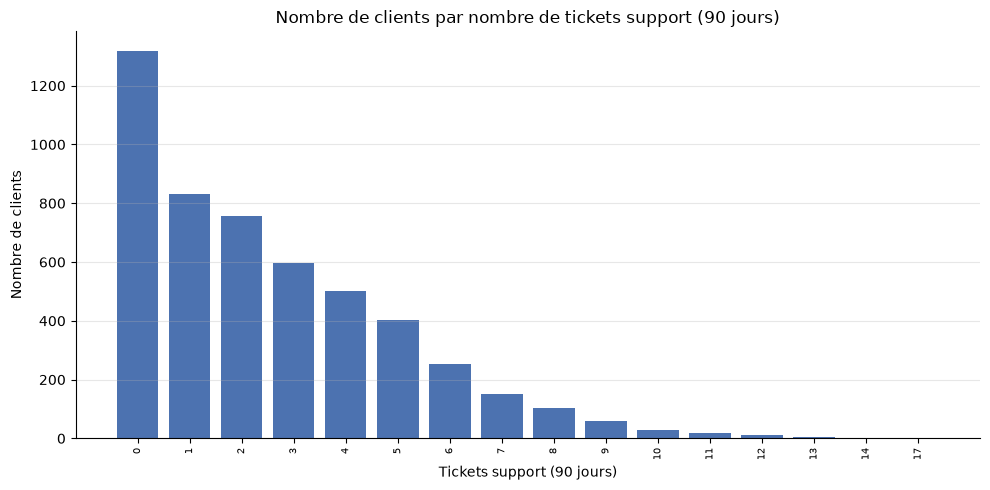

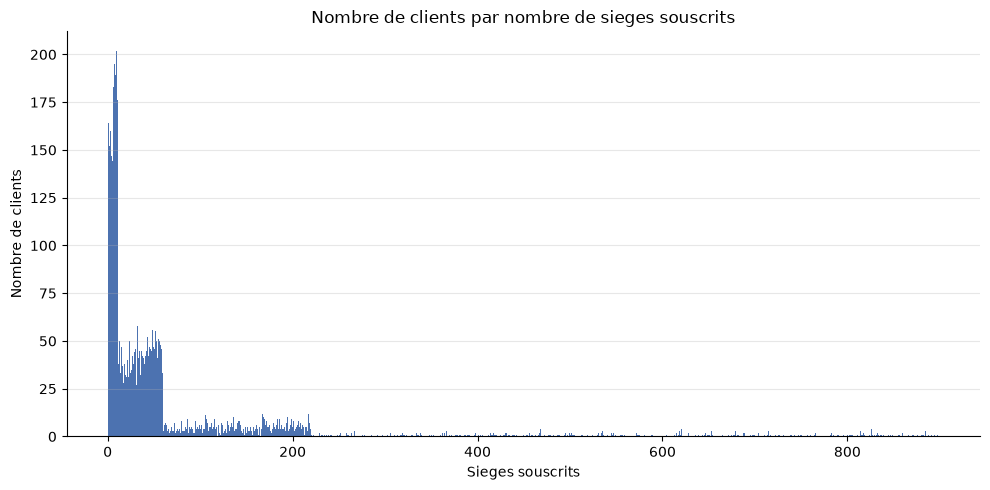

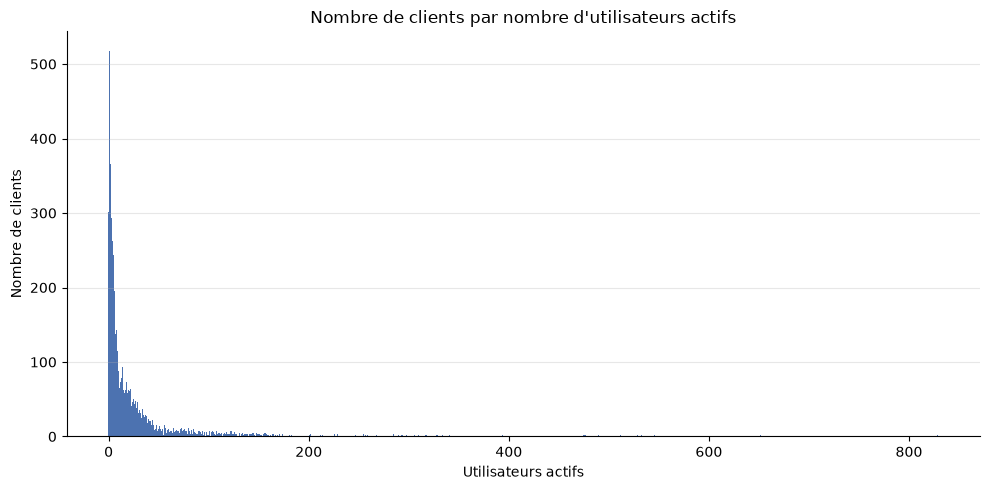

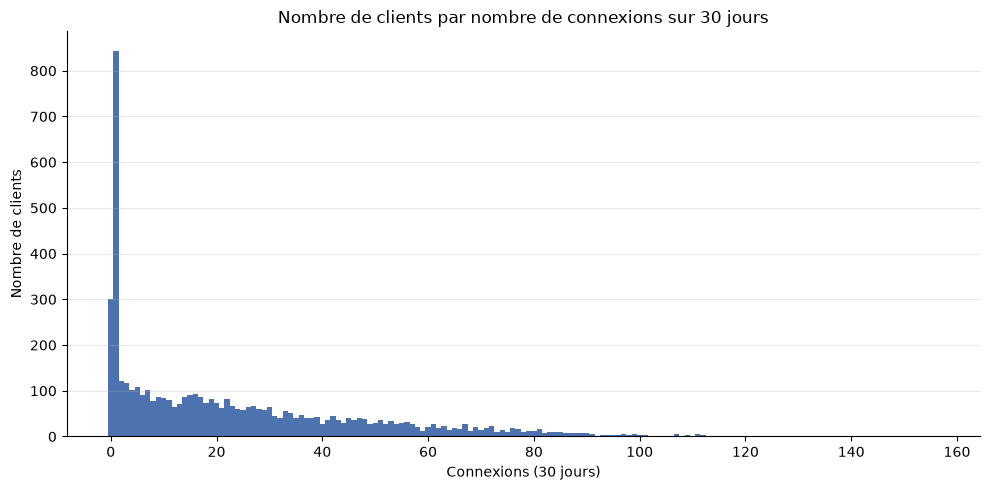

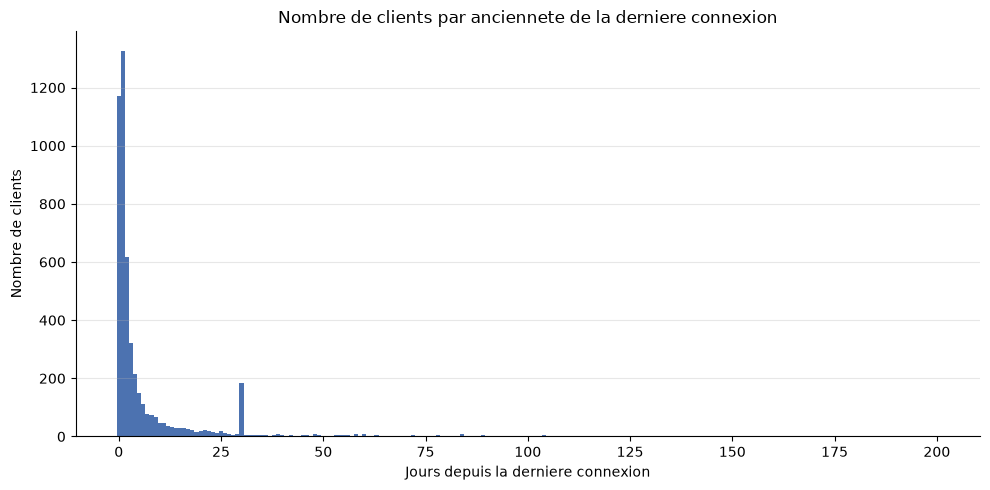

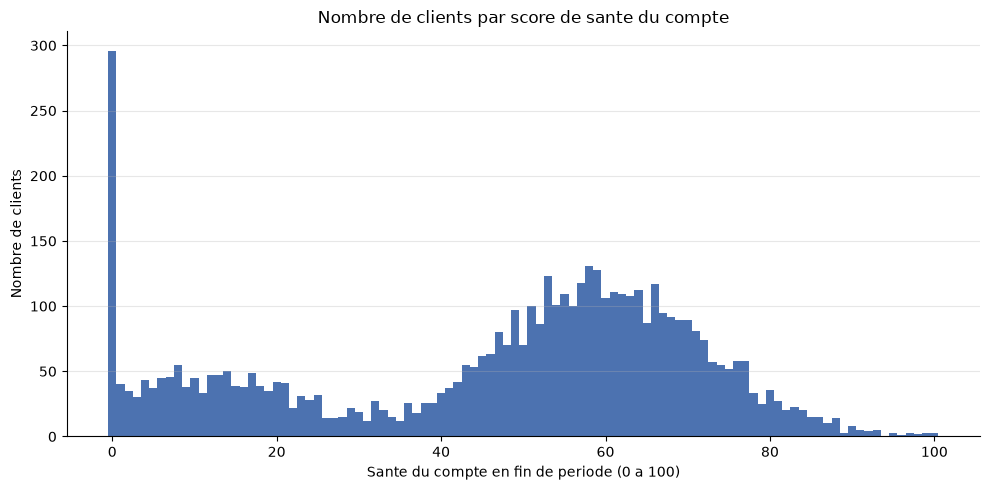

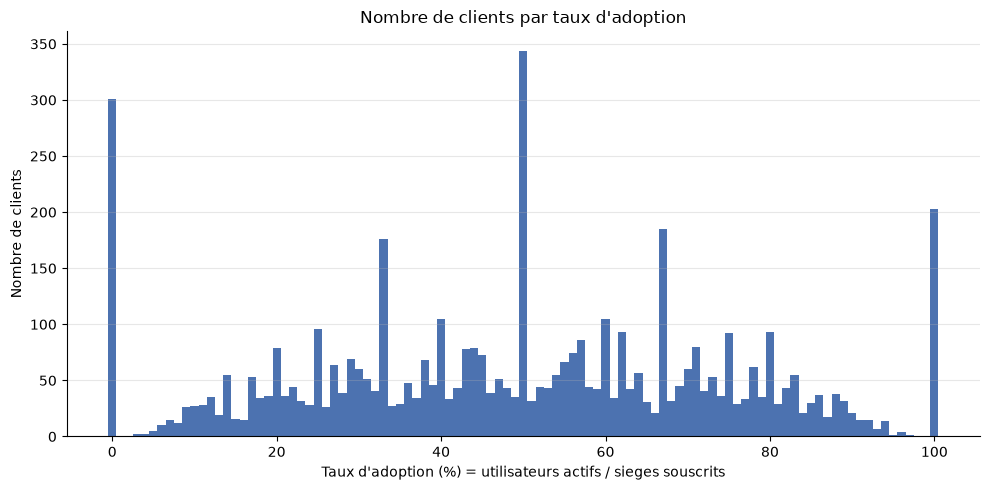

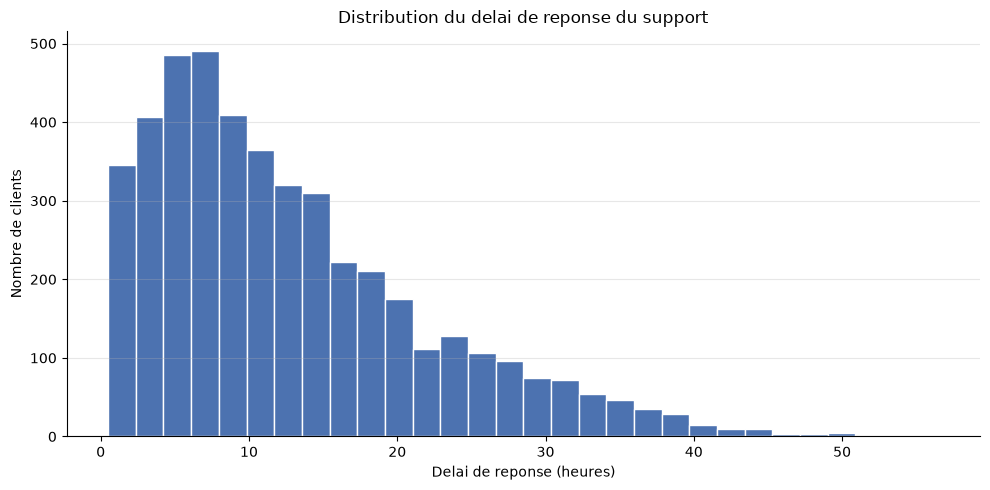

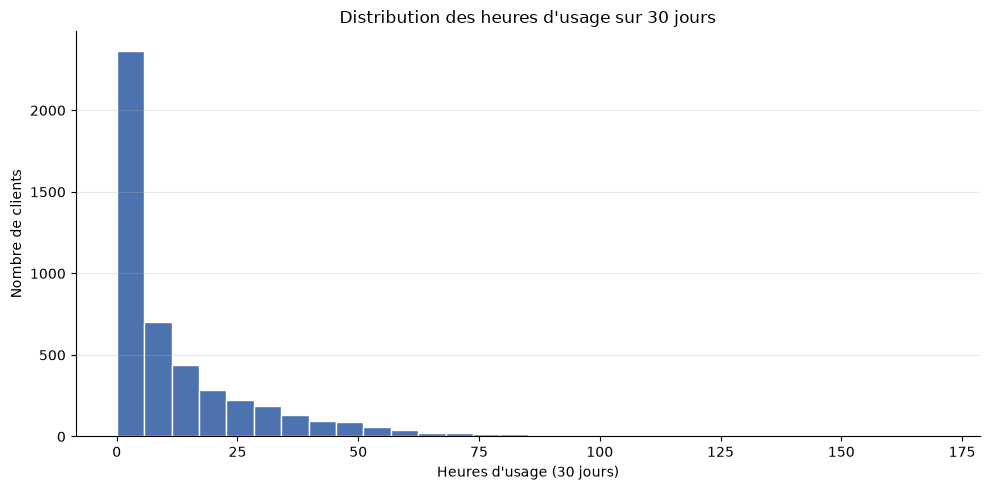

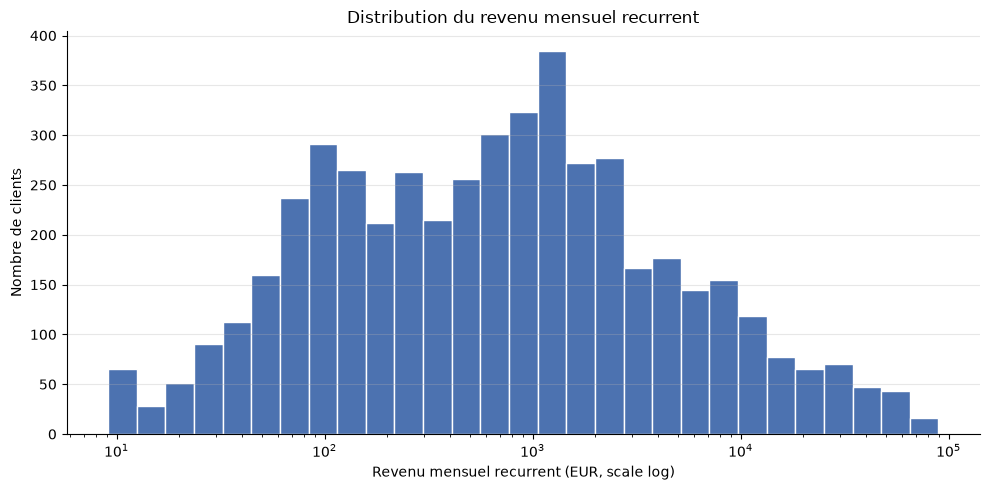

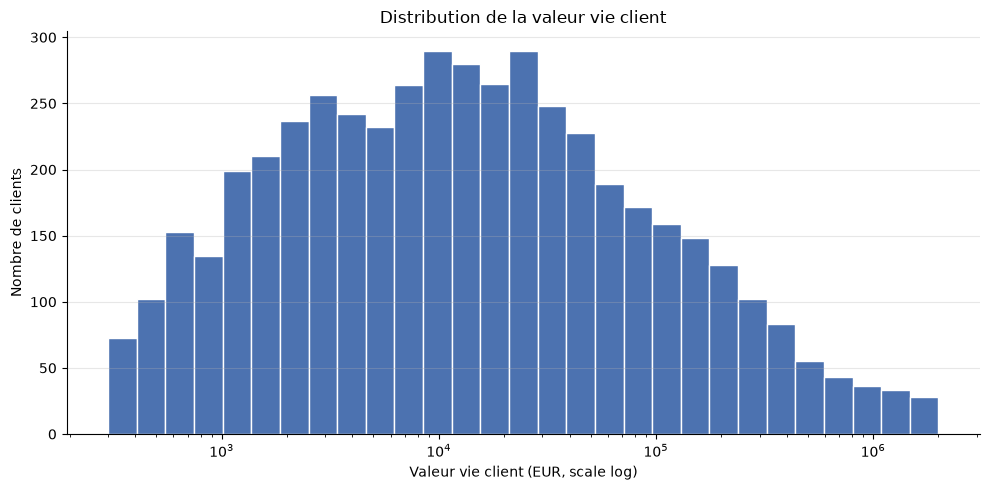

  export : src/visualization/graphs/date_souscription/histo_date_souscription.png
  export : src/visualization/graphs/jour_souscription/histo_jour_souscription.png
  export : src/visualization/graphs/secteur/histo_secteur.png
  export : src/visualization/graphs/pays/histo_pays.png
  export : src/visualization/graphs/taille_entreprise/histo_taille_entreprise.png
  export : src/visualization/graphs/plan/histo_plan.png
  export : src/visualization/graphs/anciennete_mois/histo_anciennete_mois.png
  export : src/visualization/graphs/csat/histo_csat.png
  export : src/visualization/graphs/retards_paiement_12m/histo_retards_paiement_12m.png
  export : src/visualization/graphs/nb_integrations/histo_nb_integrations.png
  export : src/visualization/graphs/tickets_support_90j/histo_tickets_support_90j.png
  export : src/visualization/graphs/sieges_souscrits/histo_sieges_souscrits.png
  export : src/visualization/graphs/utilisateurs_actifs/histo_utilisateurs_actifs.png
  export : src/visualization

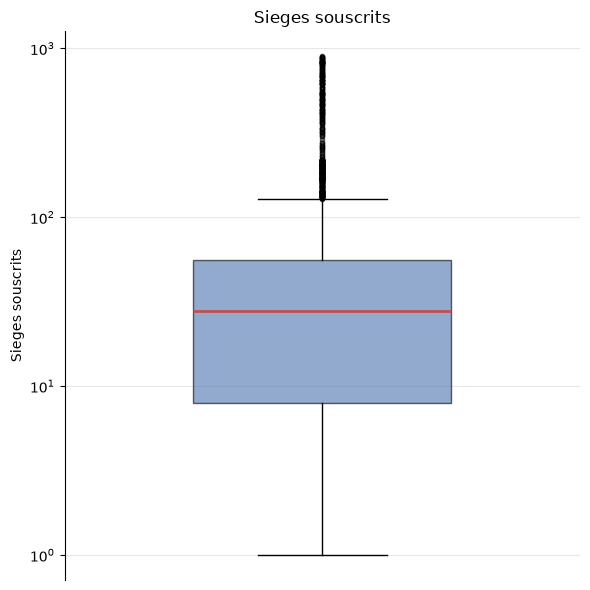

  sieges_souscrits                795 points hors moustaches (log)


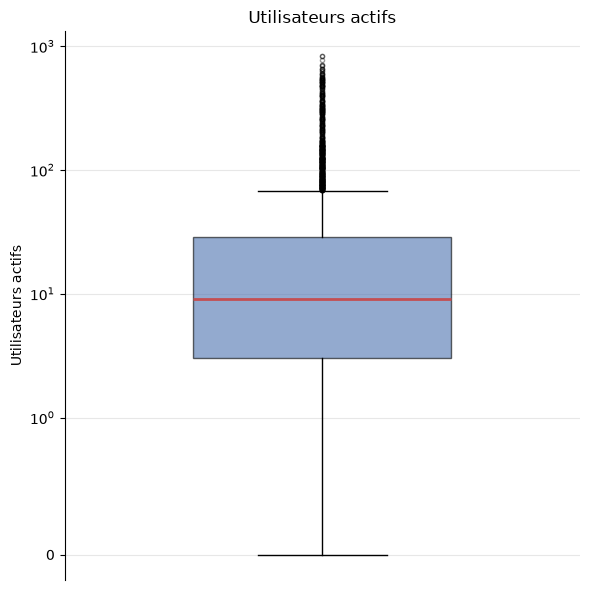

  utilisateurs_actifs             633 points hors moustaches (log)


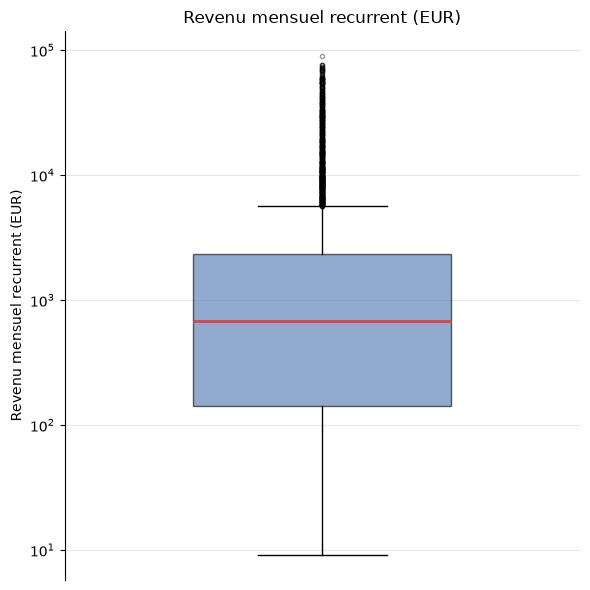

  revenu_mensuel_recurrent_eur    689 points hors moustaches (log)


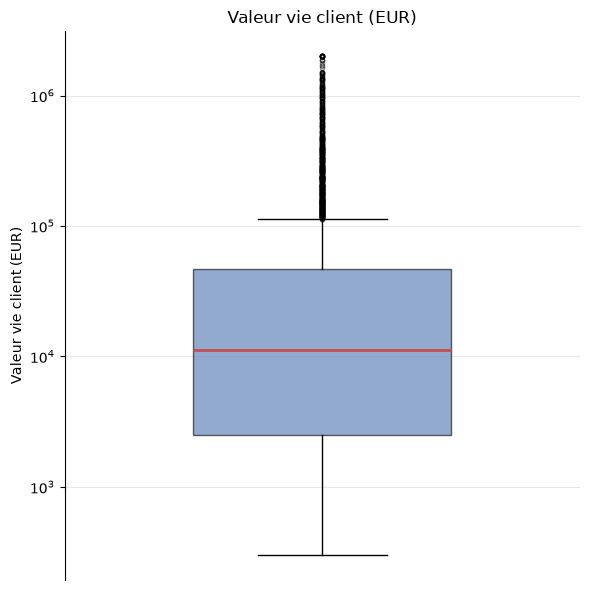

  valeur_vie_client_eur           719 points hors moustaches (log)


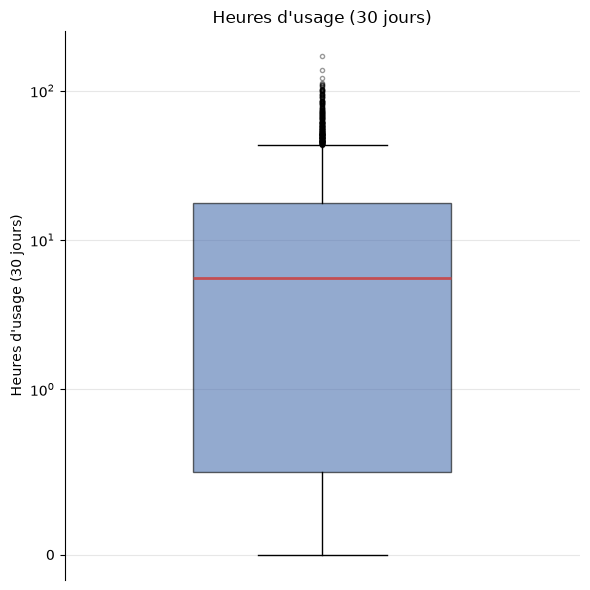

  heures_usage_30j                321 points hors moustaches (log)


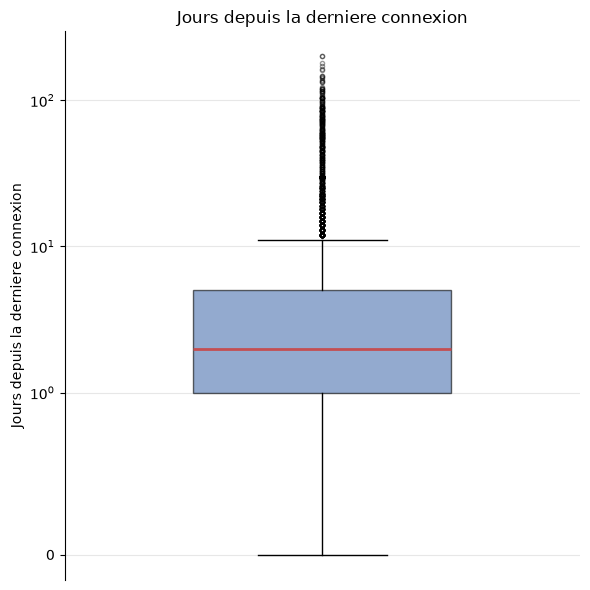

  derniere_connexion_jours        806 points hors moustaches (log)


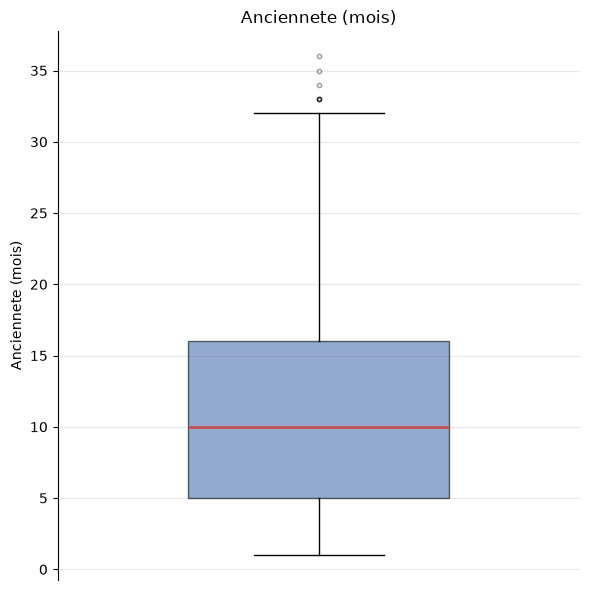

  anciennete_mois                   7 points hors moustaches (lineaire)


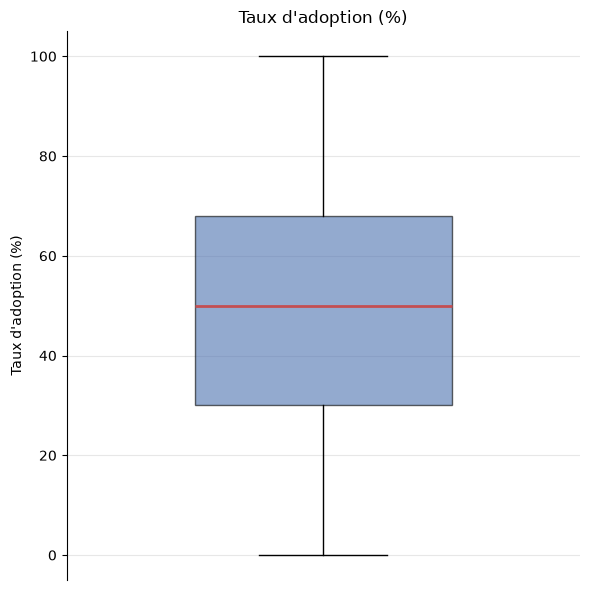

  taux_adoption_pct                 0 points hors moustaches (lineaire)


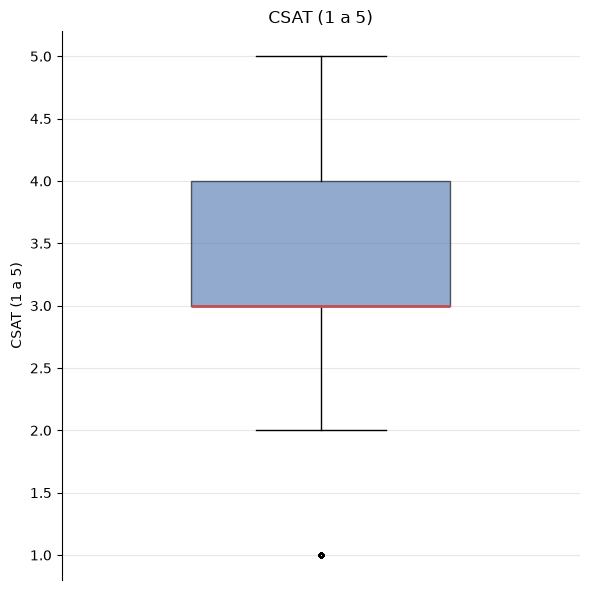

  csat                            197 points hors moustaches (lineaire)


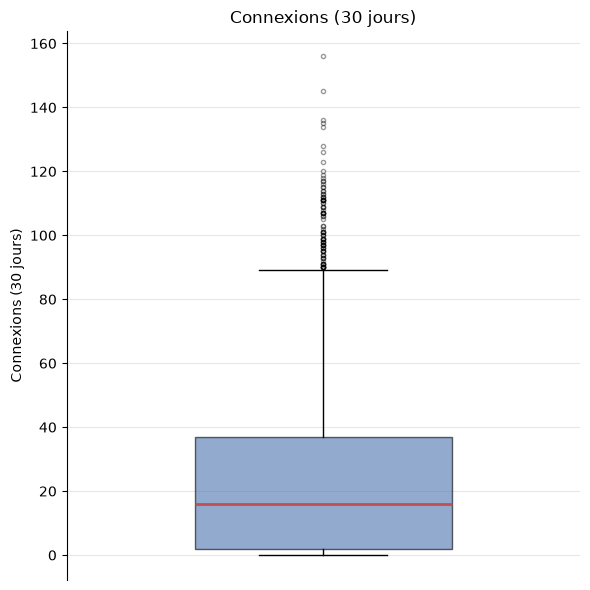

  connexions_30j                   93 points hors moustaches (lineaire)


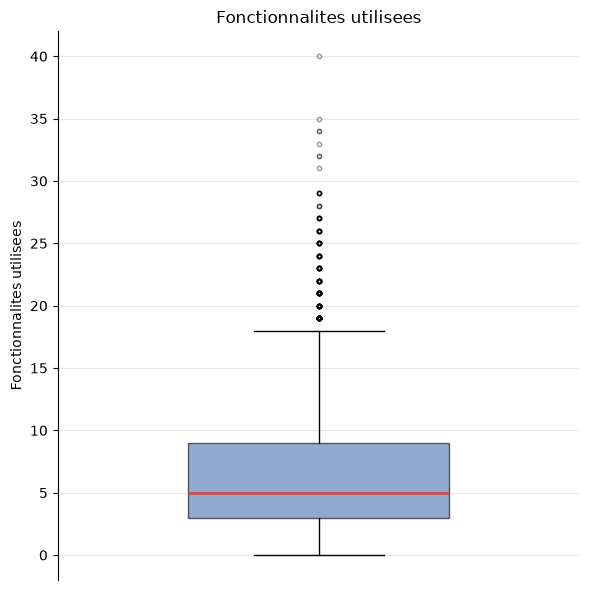

  fonctionnalites_utilisees       185 points hors moustaches (lineaire)


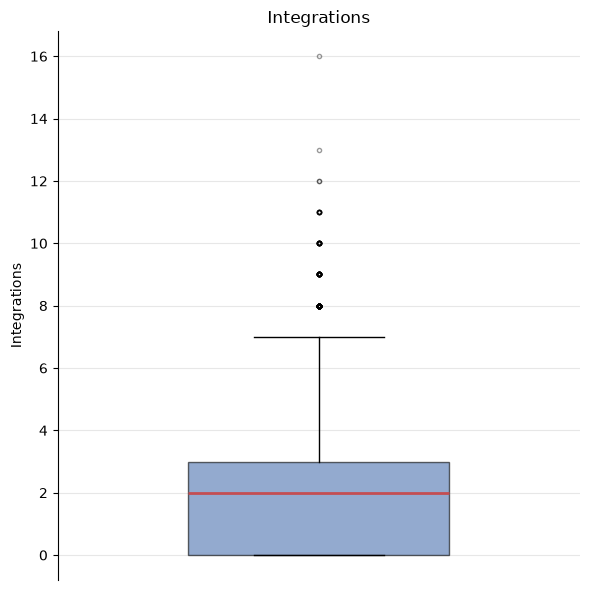

  nb_integrations                 117 points hors moustaches (lineaire)


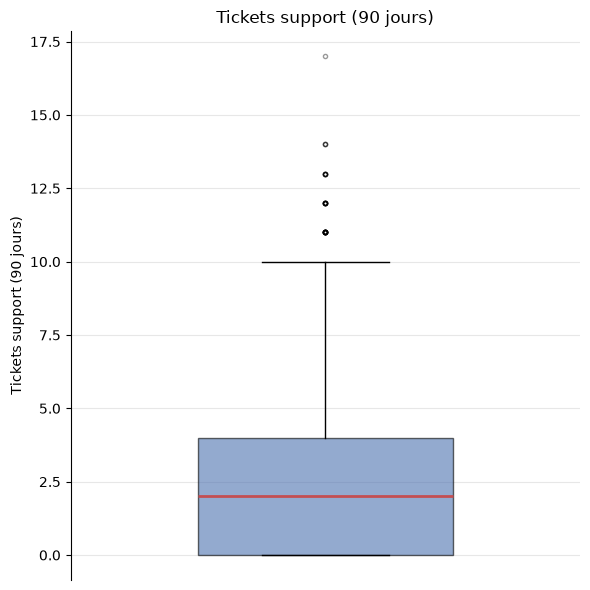

  tickets_support_90j              37 points hors moustaches (lineaire)


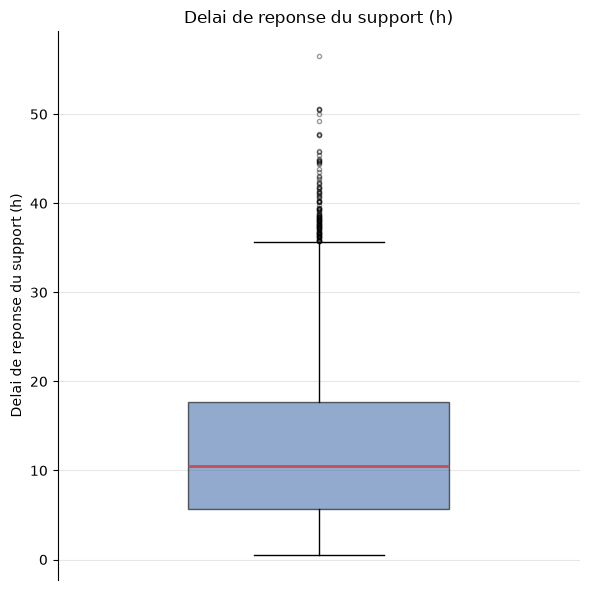

  delai_reponse_support_h         114 points hors moustaches (lineaire)


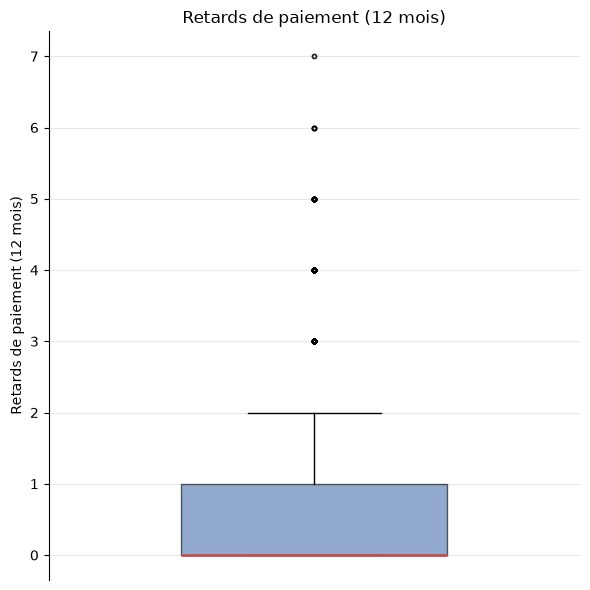

  retards_paiement_12m            422 points hors moustaches (lineaire)


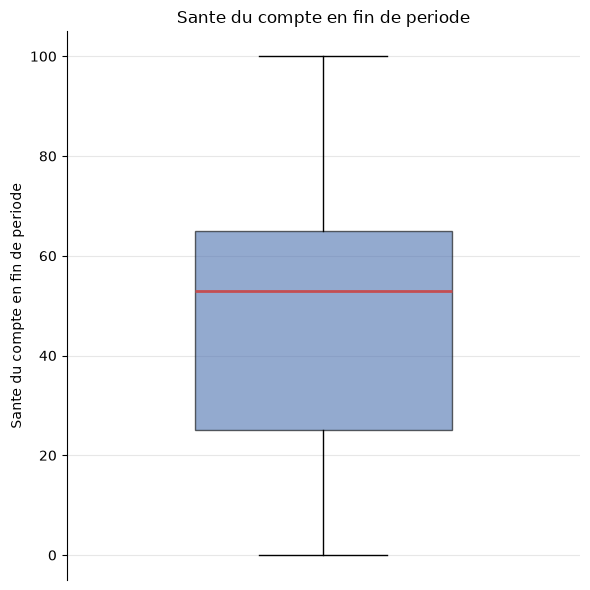

  sante_compte_fin_periode          0 points hors moustaches (lineaire)

BOITES A MOUSTACHES GROUPEES
bronze.churn_saas_complet_bronze : 5035 lignes lues


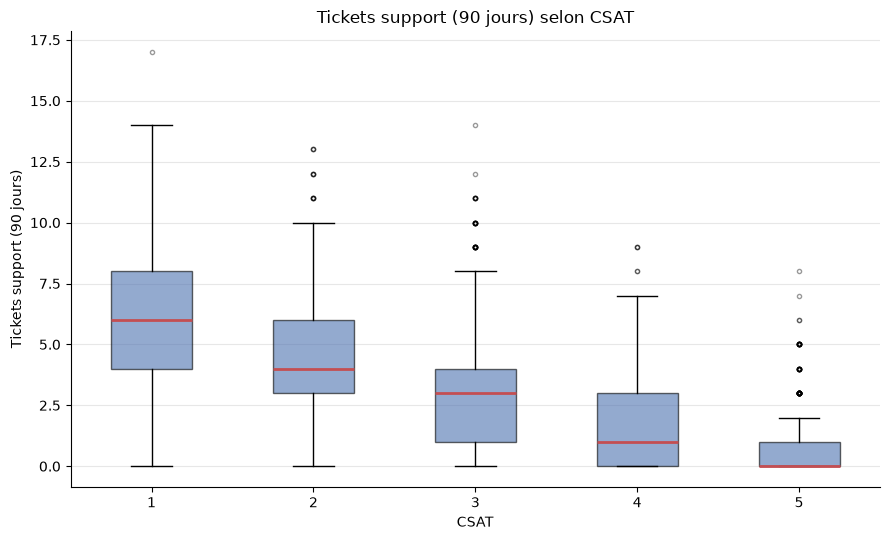

  tickets_support_90j        par csat | correlation -0.576 | medianes 1:6 2:4 3:3 4:1 5:0


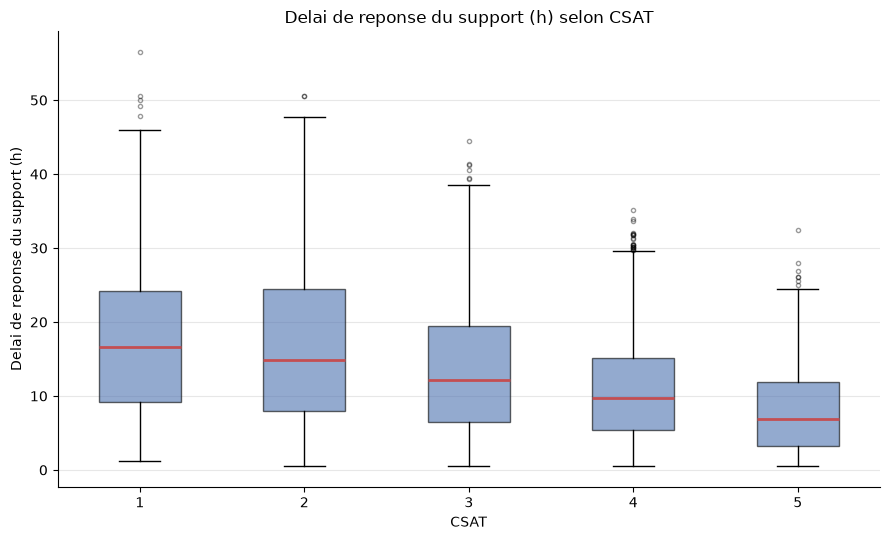

  delai_reponse_support_h    par csat | correlation -0.342 | medianes 1:16.6 2:14.9 3:12.2 4:9.7 5:6.9

TAUX DE CHURN PAR TRANCHE
bronze.churn_saas_complet_bronze : 5035 lignes lues


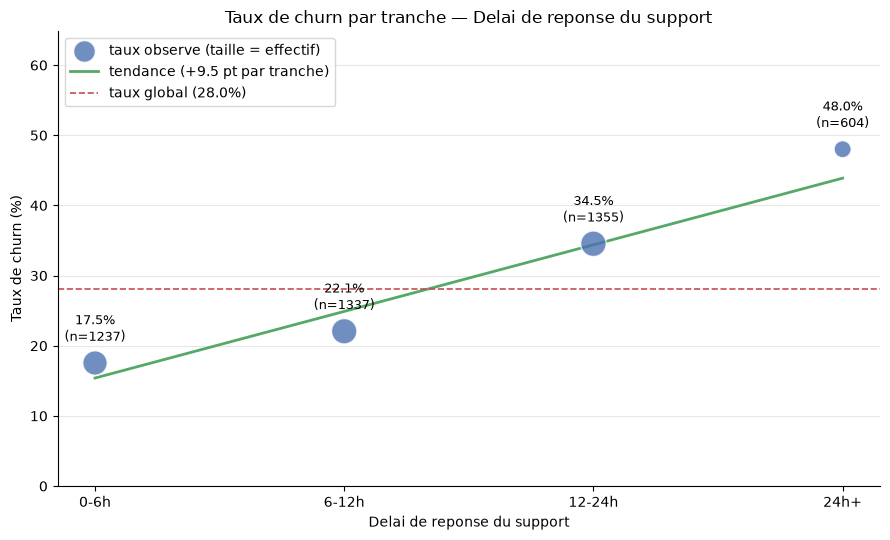

  delai_reponse_support_h    0-6h:17.5%(n=1237) 6-12h:22.1%(n=1337) 12-24h:34.5%(n=1355) 24h+:48.0%(n=604)


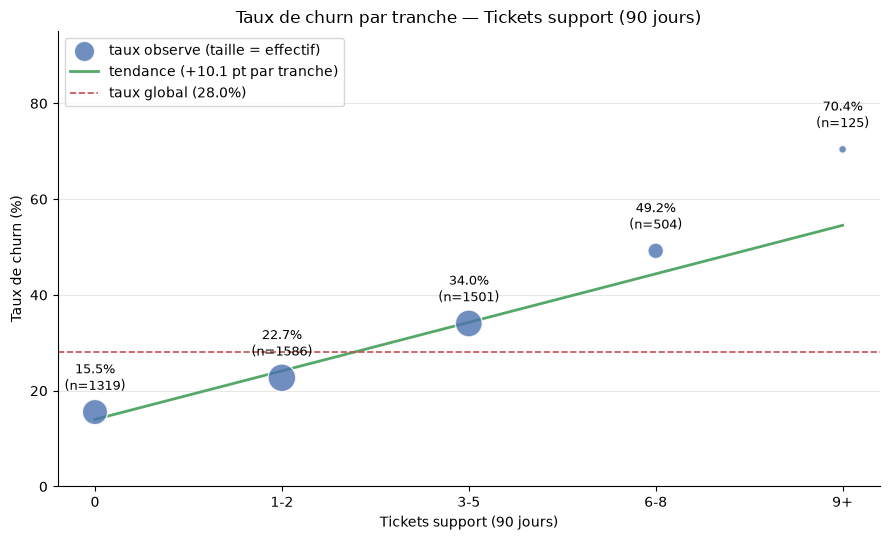

  tickets_support_90j        0:15.5%(n=1319) 1-2:22.7%(n=1586) 3-5:34.0%(n=1501) 6-8:49.2%(n=504) 9+:70.4%(n=125)


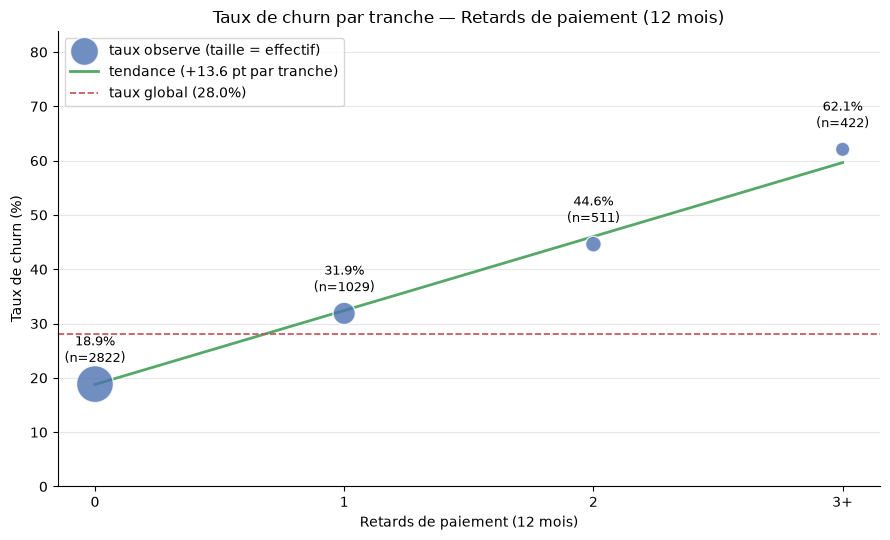

  retards_paiement_12m       0:18.9%(n=2822) 1:31.9%(n=1029) 2:44.6%(n=511) 3+:62.1%(n=422)


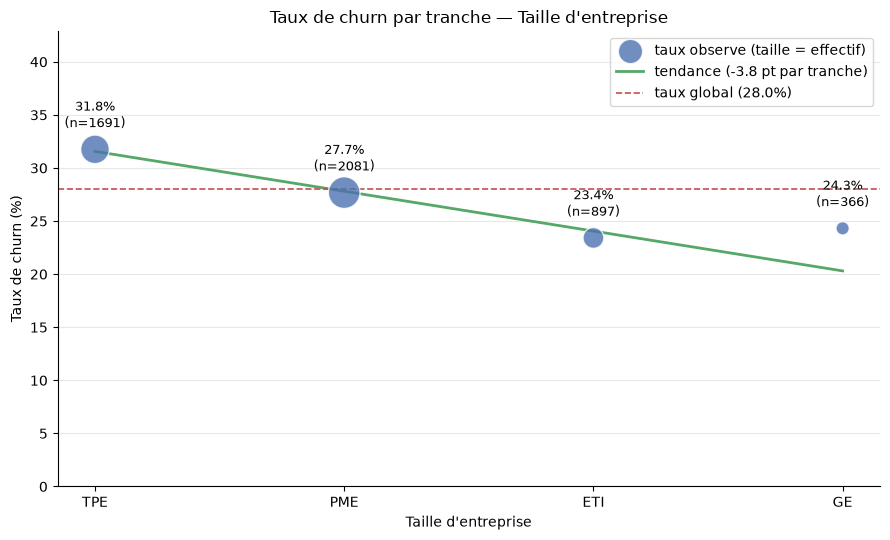

  taille_entreprise          TPE:31.8%(n=1691) PME:27.7%(n=2081) ETI:23.4%(n=897) GE:24.3%(n=366)

TAUX DE CHURN PAR VALEUR
bronze.churn_saas_complet_bronze : 5035 lignes lues


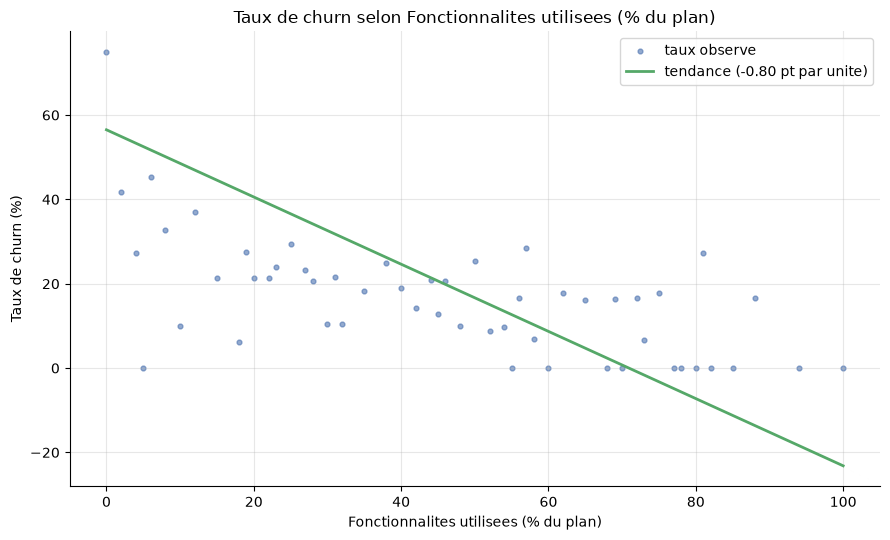

  taux_fonctionnalites       53 valeurs distinctes | tendance -0.80 pt par unite

44 graphiques generes


In [1]:
import sys

sys.path.insert(0, "src")  # src/visualization n'est pas un package installe
from visualization.scripts.plot_all import plot_all

graphiques = plot_all()

## 5. 🥉 Ingestion — couche bronze

Les trois CSV de `docs/` sont copiés **tels quels** dans le schéma `bronze` :
toutes les colonnes métier en `TEXT`, aucune conversion ni nettoyage. Chaque ligne
conserve son origine (`_source_file`, `_source_line`, `_ingested_at`).

Les tables sont vidées puis rechargées : relancer la cellule ne crée pas de
doublons. Le log compare les lignes lues dans le CSV à celles réellement insérées
en base, et signale tout écart.

In [2]:
from ml_churn.ingestion.scripts.ingest_bronze import ingest_bronze

lignes_bronze = ingest_bronze()

catalogue_plans.csv : 4 lignes lues
bronze.catalogue_bronze : 4 lignes inserees

churn_saas_complet.csv : 5035 lignes lues
bronze.churn_saas_complet_bronze : 5035 lignes inserees

churn_saas_echantillon.csv : 50 lignes lues
bronze.churn_saas_echantillon_bronze : 50 lignes inserees


TOTAL :
      - bronze.catalogue_bronze : 4 lignes
      - bronze.churn_saas_complet_bronze : 5035 lignes
      - bronze.churn_saas_echantillon_bronze : 50 lignes


## 6. 🥈 Ingestion — couche silver

`bronze.churn_saas_complet_bronze` → `silver.churn_saas_silver`, en onze actions
successives :

1. **Déduplication** sur `client_id`
2. **Standardisation** de huit colonnes : dates ramenées au format `AAAA-MM-JJ`,
   pays en codes ISO, plans en `PRO`/`BUS`/`STR`/`ENT`, casse et espaces harmonisés
3. **Règles métier** : toute ligne hors bornes est supprimée
4. **Typage** : `date`, `integer` et `numeric` selon la colonne

In [3]:
from ml_churn.ingestion.scripts.ingest_silver import ingest_silver

lignes_silver = ingest_silver()

bronze.catalogue_bronze : 4 lignes lues

[STANDARDISATION PLAN] : 4 valeurs -> 4 valeurs

[TYPAGE CATALOGUE] : 4 valeurs -> 4 valeurs

silver.catalogue_silver : 4 lignes inserees

bronze.churn_saas_complet_bronze : 5035 lignes lues

[DEDUPLICATION CLIENT_ID] : 5035 lignes -> 5000 lignes

[STANDARDISATION DATE_SOUSCRIPTION] : 5000 valeurs -> 5000 valeurs
[STANDARDISATION JOUR_SOUSCRIPTION] : 5000 valeurs -> 5000 valeurs
[STANDARDISATION SECTEUR] : 4750 valeurs -> 4750 valeurs
[STANDARDISATION PAYS] : 4800 valeurs -> 4800 valeurs
[STANDARDISATION TAILLE_ENTREPRISE] : 5000 valeurs -> 5000 valeurs
[STANDARDISATION PLAN] : 5000 valeurs -> 5000 valeurs
[STANDARDISATION COULEUR_THEME_INTERFACE] : 5000 valeurs -> 5000 valeurs
[STANDARDISATION GROUPE_EXPERIMENTATION] : 5000 valeurs -> 5000 valeurs

[DERIVATION POLARITE_CSM] : 2227 valeurs -> 5000 valeurs (ABSENT 2773, NEUTRE 947, ALERTE 873, POSITIF 407)

[REGLE CLIENT_ID] : 5000 lignes -> 5000 lignes (0)
[REGLE ANCIENNETE_MOIS] : 5000 lignes -

## 7. 🥇 Ingestion — couche gold

`silver` → `gold`, pour les deux tables : `catalogue_gold` et
`churn_saas_gold`. Les tables reprennent **la structure de silver à
l'identique** (mêmes colonnes, mêmes types) — les définitions sont partagées
via les mixins de `models/colonnes.py`, il n'y a donc pas deux schémas à
maintenir.

Gold est la couche stable sur laquelle s'appuient l'analyse et la
modélisation, sans dépendre des retraitements successifs de silver.

In [4]:
from ml_churn.ingestion.scripts.ingest_gold import ingest_gold

lignes_gold = ingest_gold()

silver.catalogue_silver : 4 lignes lues
gold.catalogue_gold : 4 lignes inserees

silver.churn_saas_silver : 5000 lignes lues
colonnes derivees : inactivite_relative, taux_fonctionnalites, inactif_30j (435 clients), niveau_anciennete (ETABLI 2011, ANCIEN 1984, RECENT 1005)
encodage one-hot : 10 colonnes categorielles -> 47 colonnes binaires
gold.churn_saas_gold : 5000 lignes inserees

TOTAL :
      - gold.catalogue_gold : 4 lignes
      - gold.churn_saas_gold : 5000 lignes


## 8. Déséquilibre de la cible

Effectifs de chaque valeur de `churn` et taux de résiliation, lus dans
`gold.churn_saas_gold`. Le code est dans `src/ml_churn/training/`.

Ce déséquilibre conditionne le choix des métriques : un modèle qui prédirait
« personne ne résilie » aurait déjà une exactitude égale à la part de clients
actifs.

In [5]:
from ml_churn.training.classification.analyze_target import analyze_target

repartition_cible = analyze_target()

churn = 0 (actif   ) : 3600 clients (72.00%)
churn = 1 (resilie ) : 1400 clients (28.00%)

taux de churn : 28.00% sur 5000 clients


## 9. Choix des Modeles

Pour le problème de classification voici la liste des modèles dont j'ai à ma disposition :

- regression logistique
- Random Forest
- XG Boost
- Gradient boosting

Pour le modèle baseline de référence je choisis de prendre la régréssion logistique car il s'agit d'un modèle simple à mettre en oeuvre et permet de résoudre un prblème catégoriel.
Le second modèle sera XGBoost car il gère les déséquilibre de classe et les meilleures performances en termce de prédiction.


## 10. Modèle de Classification

### 10.1 Entrainement du modèle baseline (régression logistique)

**Entraînement du modèle baseline.** Un modèle de regréssion logistique est utilisé pour avoir un point de référence de comparaison pour les modèles plus complèxes.
Tous les paramètres du modèle sont laissés par défaut (seuil a 0.5) et le modèle est enregistré dans `artifacts/baseline/<date>/`.

/Users/avallet/machine-learning/ml-churn/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[SEUIL] 0.50
[DONNEES] : 5000 clients, 64 features
  exclues : client_id, code_datacenter, couleur_theme_interface, date_souscription, groupe_experimentation, jour_souscription, niveau_anciennete, pays, plan, polarite_csm, sante_compte_fin_periode, secteur, taille_entreprise, valeur_vie_client_eur
  train 3000 / validation 1000 / test 1000  (churn 28.00% dans le test)

[PERFORMANCE] sur le jeu de test
  accuracy                      0.81   (TP+TN) / (TP+TN+FP+FN)
  recall                        0.80   TP / (TP+FN)
  false_positive_rate           0.19   FP / (FP+TN)
  precision                     0.62   TP / (TP+FP)
  auc                           0.88   aire sous la courbe ROC (independante du seuil)

[MATRICE DE CONFUSION]
                       predit reste       predit churn
  reel reste               TN = 584           FP = 136
  reel churn                FN = 56           TP = 224

  TP = 224   churners detectes
  FN = 56    churners manques
  FP = 136   fausses alertes
  TN = 58

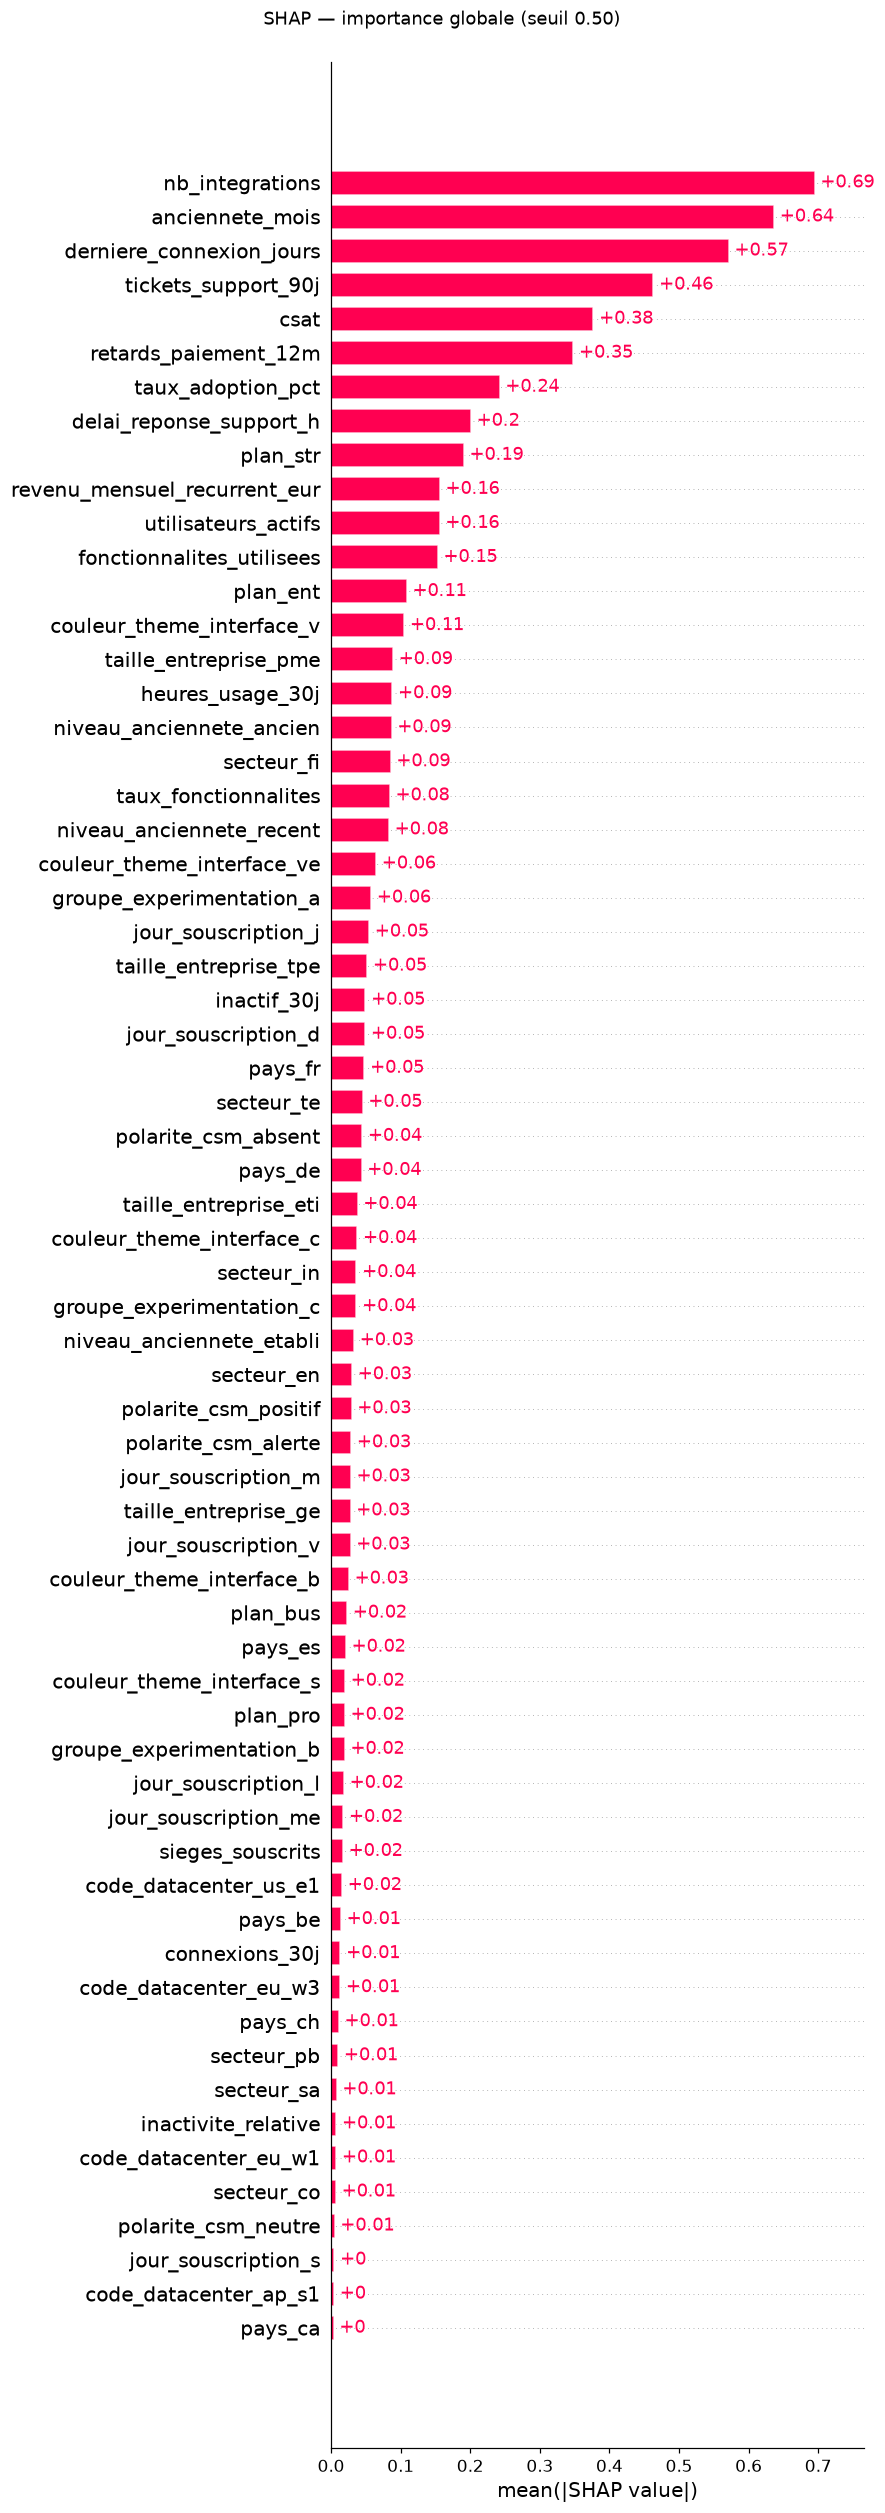

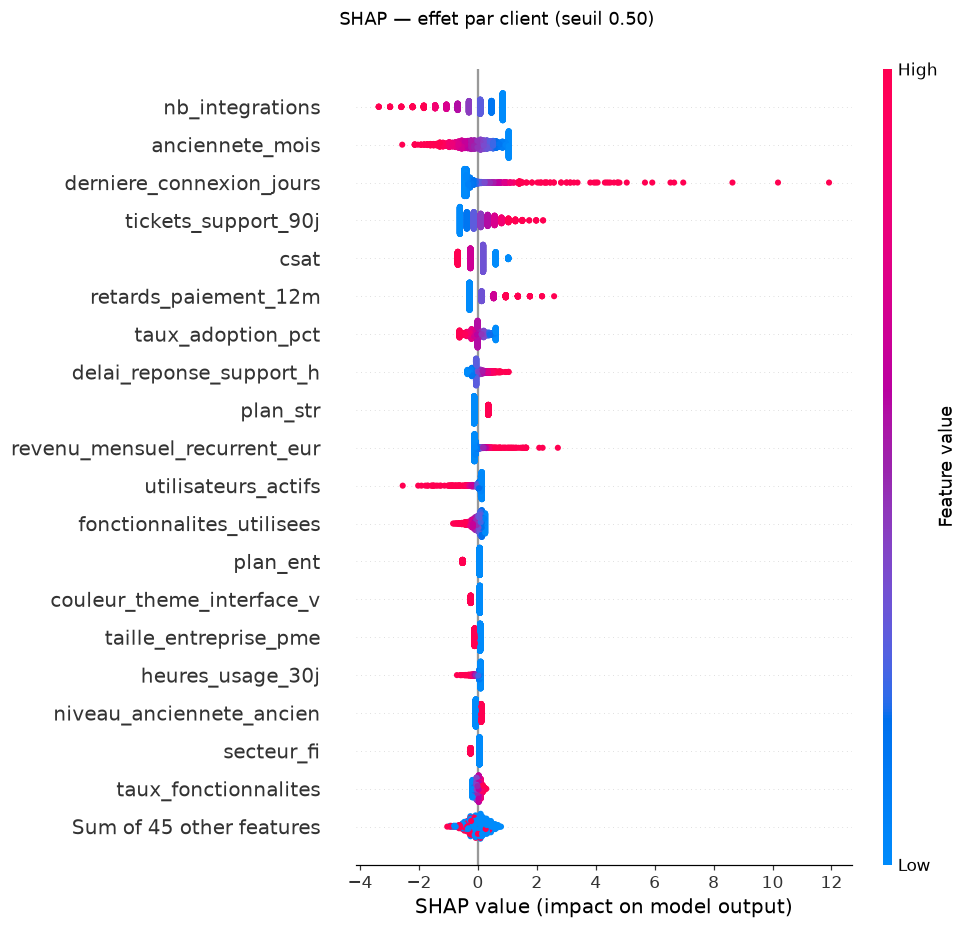

In [6]:
from ml_churn.training.classification.baseline.classification_baseline_training import (
    train_classification_baseline,
)
from ml_churn.training.common.explain import (
    display_figure,
    shap_bar_figure,
    shap_summary_figure,
)

# Seuil par defaut : 0.5.
resultat_baseline = train_classification_baseline()

# Explication sur le jeu de test : ce que le modele a appris se juge sur des
# lignes qu'il n'a pas vues.
display_figure(
    shap_bar_figure(
        resultat_baseline.model,
        resultat_baseline.X_test,
        titre=f"SHAP — importance globale (seuil {resultat_baseline.seuil:.2f})",
        max_features=None,  # toutes les colonnes, sans regroupement
    )
)
display_figure(
    shap_summary_figure(
        resultat_baseline.model,
        resultat_baseline.X_test,
        titre=f"SHAP — effet par client (seuil {resultat_baseline.seuil:.2f})",
    )
)


**Explication des features du baseline modèle avec SHAP :**

**Tableau :**
- **Hypothétisé :** Il s'agit d'une colonne dont j'ai hypothétisé ou non comme étant responsable du churn (positivement ou négativement)
- **Fortes valeurs :** impact d'une valeur forte sur le churn
- **Faibles valeurs :** impact d'une valeur faible sur le churn
- ⬆️ : impact le churn de manière positif
- ⬇️ : impact le churn de manière négative


| # | Feature | Hypothétisé | Fortes valeurs | Faibles valeurs |
|---|---------|:-----------:|:--------------:|:---------------:|
| 1 | nb_integrations | | ⬇️⬇️⬇️ | ⬆️⬆️⬆️ |
| 2 | anciennete_mois | | ⬇️⬇️⬇️ | ⬆️⬆️⬆️ |
| 3 | derniere_connexion_jours | | ⬆️⬆️⬆️ | ⬇️⬇️ |
| 4 | tickets_support_90j | ✅ | ⬆️⬆️⬆️ | ⬇️⬇️⬇️ |
| 5 | csat | ✅ | ⬇️⬇️ | ⬆️⬆️ |
| 6 | retards_paiement_12m | ✅ | ⬆️⬆️ | ⬇️⬇️ |
| 7 | taux_adoption_pct | | ⬇️⬇️ | ⬆️⬆️ |
| 8 | delai_reponse_support_h | ✅ | ⬆️⬆️ | ⬇️⬇️ |
| 9 | plan_str | | ⬆️⬆️ | ⬇️ |
| 10 | revenu_mensuel_recurrent_eur | | ⬆️⬆️ | ⬇️ |
| 11 | utilisateurs_actifs | ✅ | ⬇️⬇️ | ⬆️ |
| 12 | fonctionnalites_utilisees | ✅ | ⬇️⬇️ | ⬆️ |
| 13 | plan_ent | | ⬇️⬇️⬇️ | ⬆️ |
| 14 | couleur_theme_interface_v | | ⬇️⬇️ | ⬆️ |
| 15 | taille_entreprise_pme | ✅ | ⬇️ | ⬆️ |
| 16 | heures_usage_30j | | ⬇️ | ⬆️ |
| 17 | niveau_anciennete_ancien | | ⬆️ | ⬇️ |
| 18 | secteur_fi | | ⬇️⬇️ | ⬆️ |
| 19 | taux_fonctionnalites | | ⬆️ | ⬇️ |
| 20 | niveau_anciennete_recent | | ⬇️⬇️ | ⬆️ |

### 10.2. Classification — recherche des hyperparamètres optimaux (XGBoost)

Même cible, même découpage et mêmes exclusions que la baseline : les deux
modèles restent comparables.

La cellule enchaîne deux étapes : **recherche** sur les neuf hyperparamètres
suivants plus le seuil de décision, puis **réentraînement** avec les valeurs
retenues et mesure sur le jeu de test tenu à l'écart jusque-là — c'est ce
modèle qui est versionné dans `artifacts/` — puis les deux lectures **SHAP**
des contributions, comme pour la baseline. Les valeurs viennent ici de
`TreeExplainer`, qui parcourt les arbres au lieu de supposer un effet
linéaire.

| Hyperparamètre | Plage explorée | Rôle |
|---|---|---|
| `n_estimators` | 100 → 800 | Nombre d'arbres |
| `max_depth` | 2 → 8 | Profondeur maximale d'un arbre |
| `learning_rate` | 0.01 → 0.3 | Pas d'apprentissage entre deux arbres |
| `subsample` | 0.6 → 1.0 | Part des lignes tirées par arbre |
| `colsample_bytree` | 0.4 → 1.0 | Part des colonnes tirées par arbre |
| `min_child_weight` | 1 → 20 | Poids minimal d'une feuille |
| `gamma` | 0.0 → 5.0 | Gain minimal exigé pour un découpage |
| `reg_alpha` | 1e-8 → 10 | Pénalité L1 sur les poids des feuilles |
| `reg_lambda` | 1e-8 → 10 | Pénalité L2 sur les poids des feuilles |
| `seuil` | 0.1 → 0.9 | Probabilité à partir de laquelle on alerte |

Les Hyperparamètres finaux et le seuil sont les suivants :


| Hyperparamètre | Valeur |
|---|---:|
| `seuil` | 0.40 |
| `n_estimators` | 300 |
| `max_depth` | 2 |
| `learning_rate` | 0.02 |
| `subsample` | 0.96 |
| `colsample_bytree` | 0.79 |
| `min_child_weight` | 8 |
| `gamma` | 4.58 |
| `reg_alpha` | 0.00 |
| `reg_lambda` | 3.58 |

Performances observées, sur la validation qui a servi à retenir ces valeurs
puis sur le test tenu à l'écart :

| Métrique | Validation | Test |
|---|---:|---:|
| score F2 | 0.78 | 0.78 |
| recall | 0.87 | 0.88 |
| false_positive_rate | 0.29 | 0.29 |
| precision | 0.54 | 0.54 |
| accuracy | 0.76 | 0.75 |
| auc | 0.88 | 0.87 |

Conclusion : l'écart entre validation et test est nul à deux décimales, la
recherche ne s'est donc pas sur-ajustée à la validation.


[RECHERCHE] hyperparametres XGBoost, 100 essais
  train 3000 / validation 1000 / test 1000  (64 features, scale_pos_weight 2.57)

[OBJECTIF] f2 : le rappel pese 4 fois la precision

    essai    score   seuil   recall  precision     FPR     auc
    1/100     0.53    0.70     0.50       0.71    0.08    0.86  <- meilleur
    2/100     0.73    0.30     0.79       0.55    0.25    0.85  <- meilleur
    3/100     0.75    0.10     0.99       0.38    0.64    0.88  <- meilleur
    4/100     0.76    0.45     0.81       0.59    0.22    0.88  <- meilleur
    5/100     0.75    0.25     0.97       0.39    0.59    0.88
    6/100     0.68    0.35     0.70       0.59    0.19    0.85
    7/100     0.40    0.90     0.35       0.82    0.03    0.86
    8/100     0.76    0.15     0.98       0.40    0.57    0.88  <- meilleur
    9/100     0.70    0.50     0.73       0.62    0.17    0.87
   10/100     0.76    0.15     0.93       0.44    0.45    0.86  <- meilleur
   11/100     0.59    0.70     0.56       0.72 

2026/09/26 19:02:22 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/avallet/machine-learning/ml-churn
/Users/avallet/machine-learning/ml-churn/.venv/lib/python3.13/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/Users/avallet/machine-learning/ml-churn/.venv/lib/python3.13/site


[HYPERPARAMETRES RETENUS] f2 = 0.79 en validation
  seuil 0.40
  n_estimators         300
  max_depth            2
  learning_rate        0.02
  subsample            0.96
  colsample_bytree     0.76
  min_child_weight     8
  gamma                4.57
  reg_alpha            0.00
  reg_lambda           4.62

[PERFORMANCE] sur le jeu de test, au seuil retenu
  accuracy              0.76
  recall                0.88
  false_positive_rate   0.29
  precision             0.54
  auc                   0.87

[MEILLEURS ESSAIS] les 5 premiers
    essai    score   seuil   recall  precision     FPR     auc
       66     0.79    0.40     0.89       0.54    0.29    0.88
       67     0.78    0.40     0.88       0.54    0.29    0.88
       86     0.78    0.35     0.91       0.50    0.36    0.88
       49     0.78    0.35     0.92       0.49    0.37    0.88
       65     0.78    0.40     0.88       0.54    0.29    0.88

  runs enregistres dans /Users/avallet/machine-learning/ml-churn/mlflow.db (uv ru

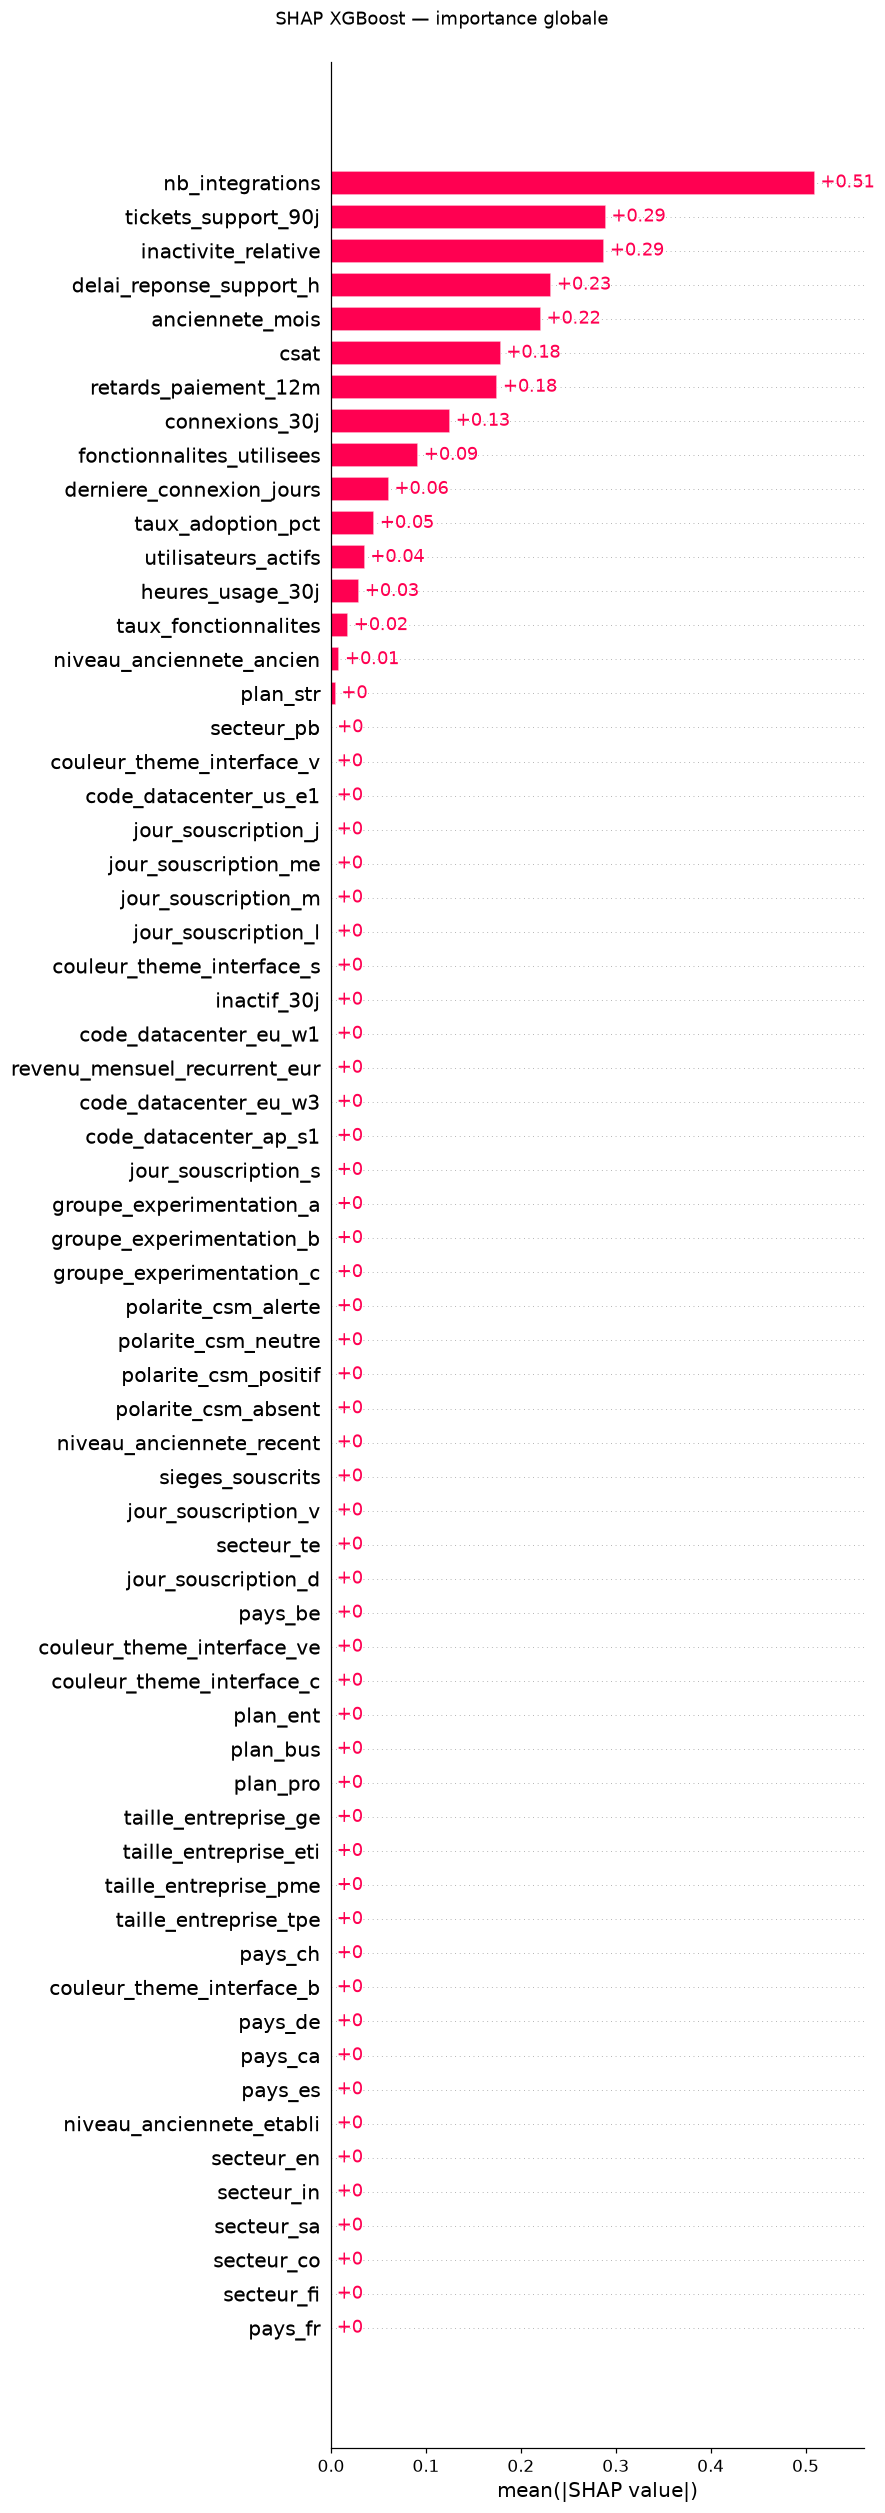

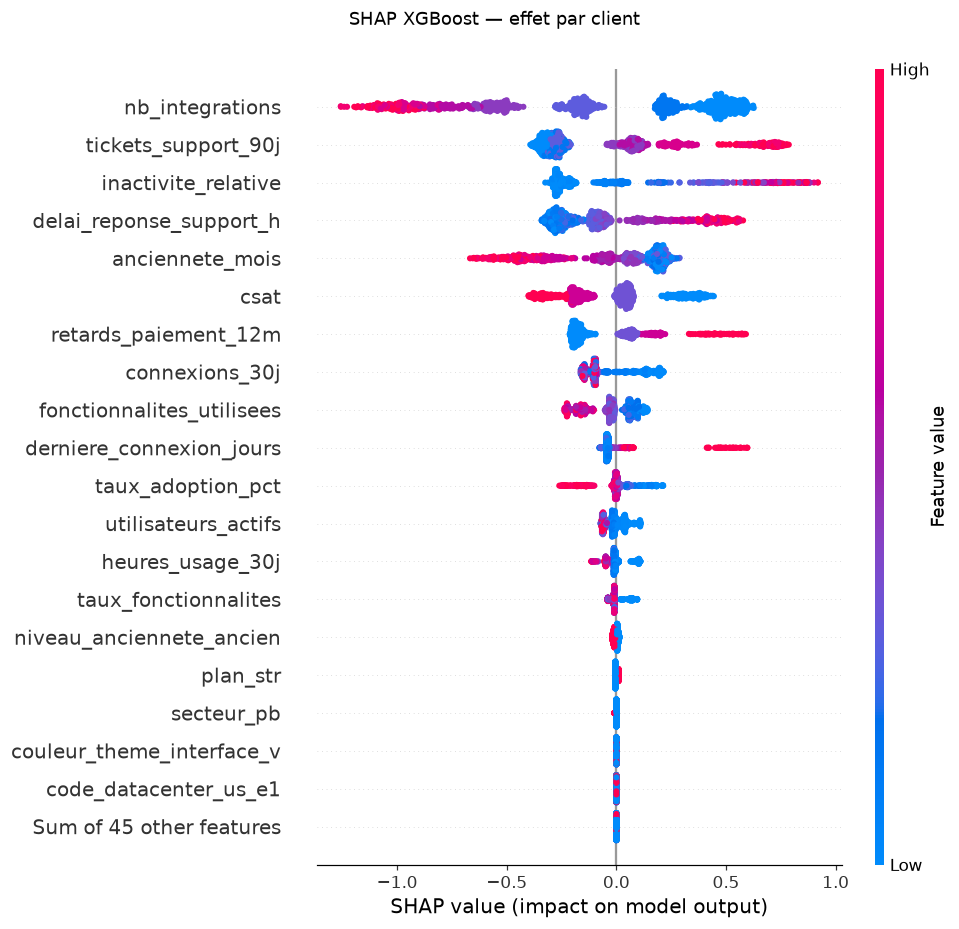

In [7]:
from ml_churn.training.classification.final.classification_xgboost_training import (
    train_classification_xgboost,
)
from ml_churn.training.classification.final.classification_xgboost_tuning import (
    tune_xgboost,
)
from ml_churn.training.common.explain import (
    display_figure,
    shap_bar_figure,
    shap_summary_figure,
)

# 1. Recherche des hyperparametres : un modele reentraine par essai.
resultat_tuning_xgboost = tune_xgboost(n_essais=100)

# 2. Reentrainement avec les hyperparametres retenus, puis mesure sur le jeu de
# test tenu a l'ecart. Ce modele n'est pas enregistre : seul le modele reduit
# de la section suivante l'est.
resultat_xgboost = train_classification_xgboost(
    seuil=resultat_tuning_xgboost.seuil,
    hyperparametres=resultat_tuning_xgboost.hyperparametres,
    enregistrer=False,
)

# 3. Explication du modele sur le jeu de test.
display_figure(
    shap_bar_figure(
        resultat_xgboost.model,
        resultat_xgboost.X_test,
        titre="SHAP XGBoost — importance globale",
        max_features=None,  # toutes les colonnes, sans regroupement
    )
)
display_figure(
    shap_summary_figure(
        resultat_xgboost.model,
        resultat_xgboost.X_test,
        titre="SHAP XGBoost — effet par client",
    )
)

### 10.3. Classification — XGBoost, modèle réduit

De nombreuses features ont un très faible impact sur le modèle établie précédement, on va retirer les features suivantes :

| Colonne retirée | Modalités concernées |
|---|---|
| `groupe_experimentation` | `_a`, `_b`, `_c` |
| `code_datacenter` | `_eu_w1`, `_eu_w3`, `_us_e1`, `_ap_s1` |
| `couleur_theme_interface` | `_c`, `_ve`, `_b`, `_v`, `_s` |
| `plan` | `_str`, `_pro`, `_bus`, `_ent` |
| `taille_entreprise` | `_tpe`, `_pme`, `_eti`, `_ge` |
| `pays` | `_fr`, `_es`, `_ca`, `_de`, `_ch`, `_be` |
| `jour_souscription` | `_l`, `_m`, `_me`, `_j`, `_v`, `_s`, `_d` |
| `secteur` | `_te`, `_fi`, `_co`, `_sa`, `_in`, `_pb`, `_en` |

Entrainement d'un nouveau modèle avec exclusion des features :

Performances observées sur le test set, face au modèle baseline :

| Métrique | Baseline (seuil 0.5) | XGBoost réduit (seuil 0.4) |
|---|---:|---:|
| features | 64 | 24 |
| accuracy | 0.81 | 0.76 |
| recall | 0.80 | 0.87 |
| false_positive_rate | 0.19 | 0.29 |
| precision | 0.62 | 0.54 |
| auc | 0.88 | 0.87 |

Conclusion : le modèle XGBoost optimisé arrive à avoir une capacité de détection des churn légérement meilleur que le baseline (recall +7%) mais au prix de plus d'alertes (+10%).
On constate également que les features polarité_X (correspondant aux commentaires csm) ont aucun d'impact sur le modèle ce qui est contre-intuitif étant donné la pertinance évidante de cette donnée.


[ENTRAINEMENT] XGBoost sur 3000 lignes de train

[SEUIL] 0.40

[HYPERPARAMETRES]
  n_estimators         300
  max_depth            2
  learning_rate        0.02
  subsample            0.96
  colsample_bytree     0.76
  min_child_weight     8
  gamma                4.57
  reg_alpha            0.00
  reg_lambda           4.62
[DONNEES] : 5000 clients, 24 features
  exclues : client_id, code_datacenter, code_datacenter_ap_s1, code_datacenter_eu_w1, code_datacenter_eu_w3, code_datacenter_us_e1, couleur_theme_interface, couleur_theme_interface_b, couleur_theme_interface_c, couleur_theme_interface_s, couleur_theme_interface_v, couleur_theme_interface_ve, date_souscription, groupe_experimentation, groupe_experimentation_a, groupe_experimentation_b, groupe_experimentation_c, jour_souscription, jour_souscription_d, jour_souscription_j, jour_souscription_l, jour_souscription_m, jour_souscription_me, jour_souscription_s, jour_souscription_v, niveau_anciennete, pays, pays_be, pays_ca, pays_ch, pay

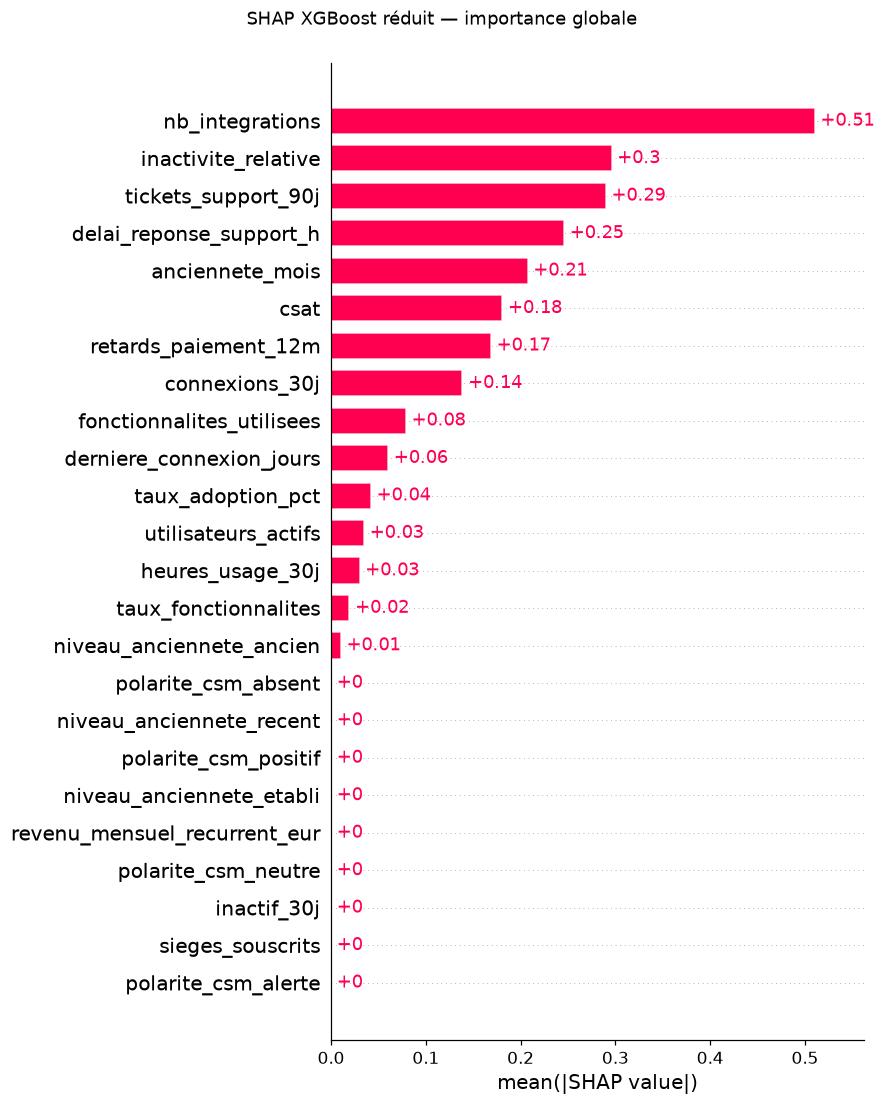

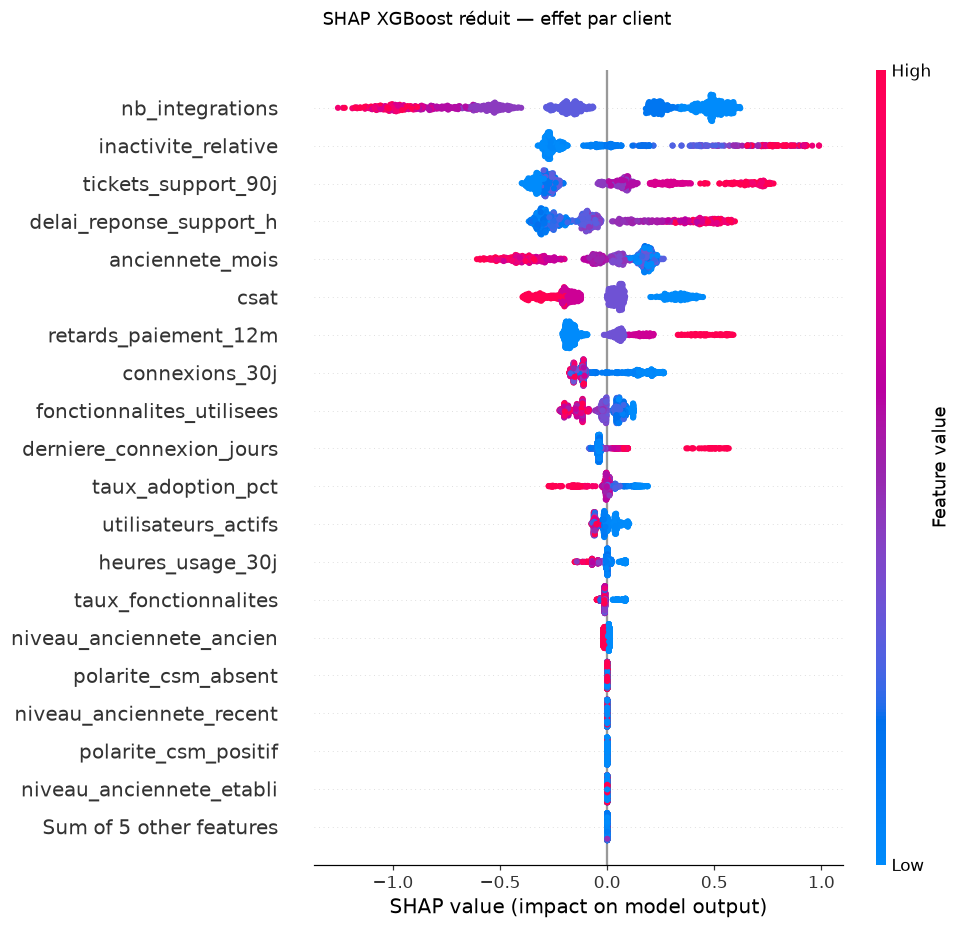

In [8]:
from ml_churn.training.classification.final.classification_xgboost_training import (
    COLONNES_RETIREES,
    exclusions_sans,
    train_classification_xgboost,
)
from ml_churn.training.common.explain import (
    display_figure,
    shap_bar_figure,
    shap_summary_figure,
)

resultat_xgboost_reduit = train_classification_xgboost(
    seuil=resultat_tuning_xgboost.seuil,
    hyperparametres=resultat_tuning_xgboost.hyperparametres,
    exclusions=exclusions_sans(COLONNES_RETIREES),
)

# Explication du modele reduit sur le jeu de test.
display_figure(
    shap_bar_figure(
        resultat_xgboost_reduit.model,
        resultat_xgboost_reduit.X_test,
        titre="SHAP XGBoost réduit — importance globale",
        max_features=None,  # toutes les colonnes, sans regroupement
    )
)
display_figure(
    shap_summary_figure(
        resultat_xgboost_reduit.model,
        resultat_xgboost_reduit.X_test,
        titre="SHAP XGBoost réduit — effet par client",
    )
)

## 13. Régression — sélection des features

Deux couches, deux usages.

Les **figures** sont construites sur la **silver** : 17 colonnes numériques,
une par variable métier, soit une matrice qu'on peut lire case par case.

Les **logs** reprennent la silver puis la **gold**, celle que les modèles
consomment réellement. Ses 67 colonnes — modalités one-hot comprises — donnent
une figure illisible, mais son classement révèle des features absentes de la
silver : `taille_entreprise_ge` y arrive 4ᵉ à +0.67, alors qu'en silver
`taille_entreprise` est une colonne texte, donc hors matrice.

Deux lectures :

**La colonne `valeur_vie_client_eur`** désigne les features candidates —
celles qui portent un signal sur la cible.

**Les paires fortement corrélées entre elles** signalent la redondance. Deux
features qui disent la même chose se partagent le crédit dans une régression
linéaire : leurs coefficients deviennent instables, parfois de signes opposés,
sans que la prédiction change. Le seuil d'alerte est fixé à 0.8.

La seconde matrice ne garde que les corrélations marquantes — au-dessus de 0.5
ou en dessous de −0.2, diagonale exclue. La bande est asymétrique : les
corrélations négatives sont plus rares ici, donc informatives plus tôt.


[CORRELATION] couche silver, avec valeur_vie_client_eur, les 10 plus fortes
  revenu_mensuel_recurrent_eur   +0.84  (augmente la cible)
  sieges_souscrits               +0.76  (augmente la cible)
  utilisateurs_actifs            +0.70  (augmente la cible)
  fonctionnalites_utilisees      +0.30  (augmente la cible)
  delai_reponse_support_h        -0.26  (diminue  la cible)
  sante_compte_fin_periode       +0.11  (augmente la cible)
  anciennete_mois                +0.08  (augmente la cible)
  churn                          -0.07  (diminue  la cible)
  heures_usage_30j               +0.06  (augmente la cible)
  nb_integrations                +0.04  (augmente la cible)

[REDONDANCE] couche silver, paires au-dela de 80%
  revenu_mensuel_recurrent_eur   sieges_souscrits               +0.92
  churn                          sante_compte_fin_periode       -0.88
  connexions_30j                 heures_usage_30j               +0.87
  sieges_souscrits               utilisateurs_actifs          

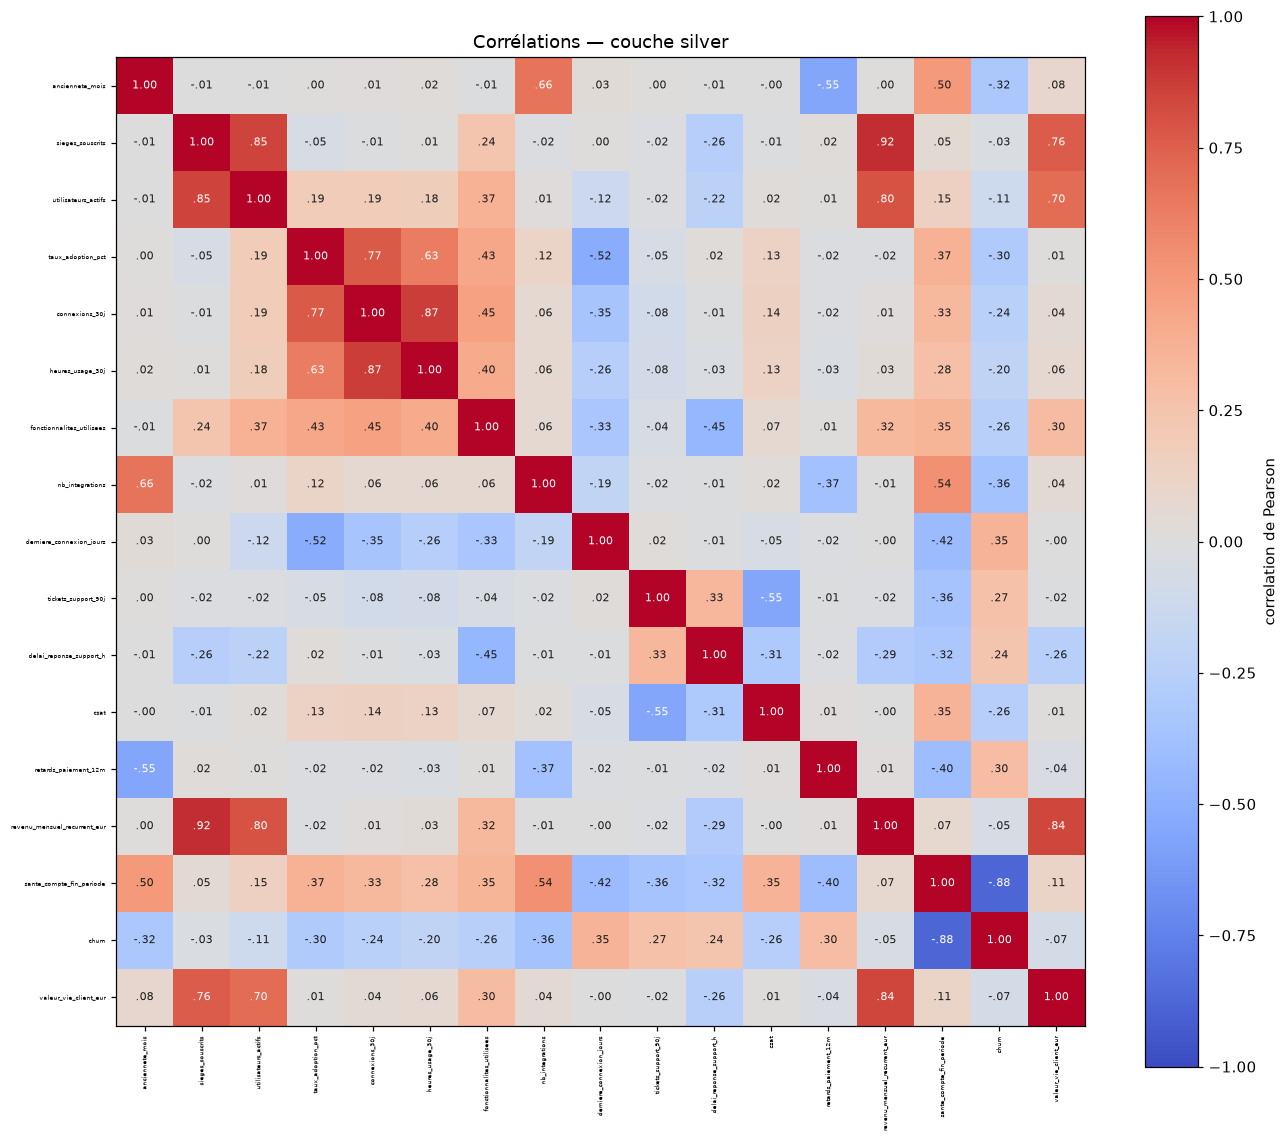

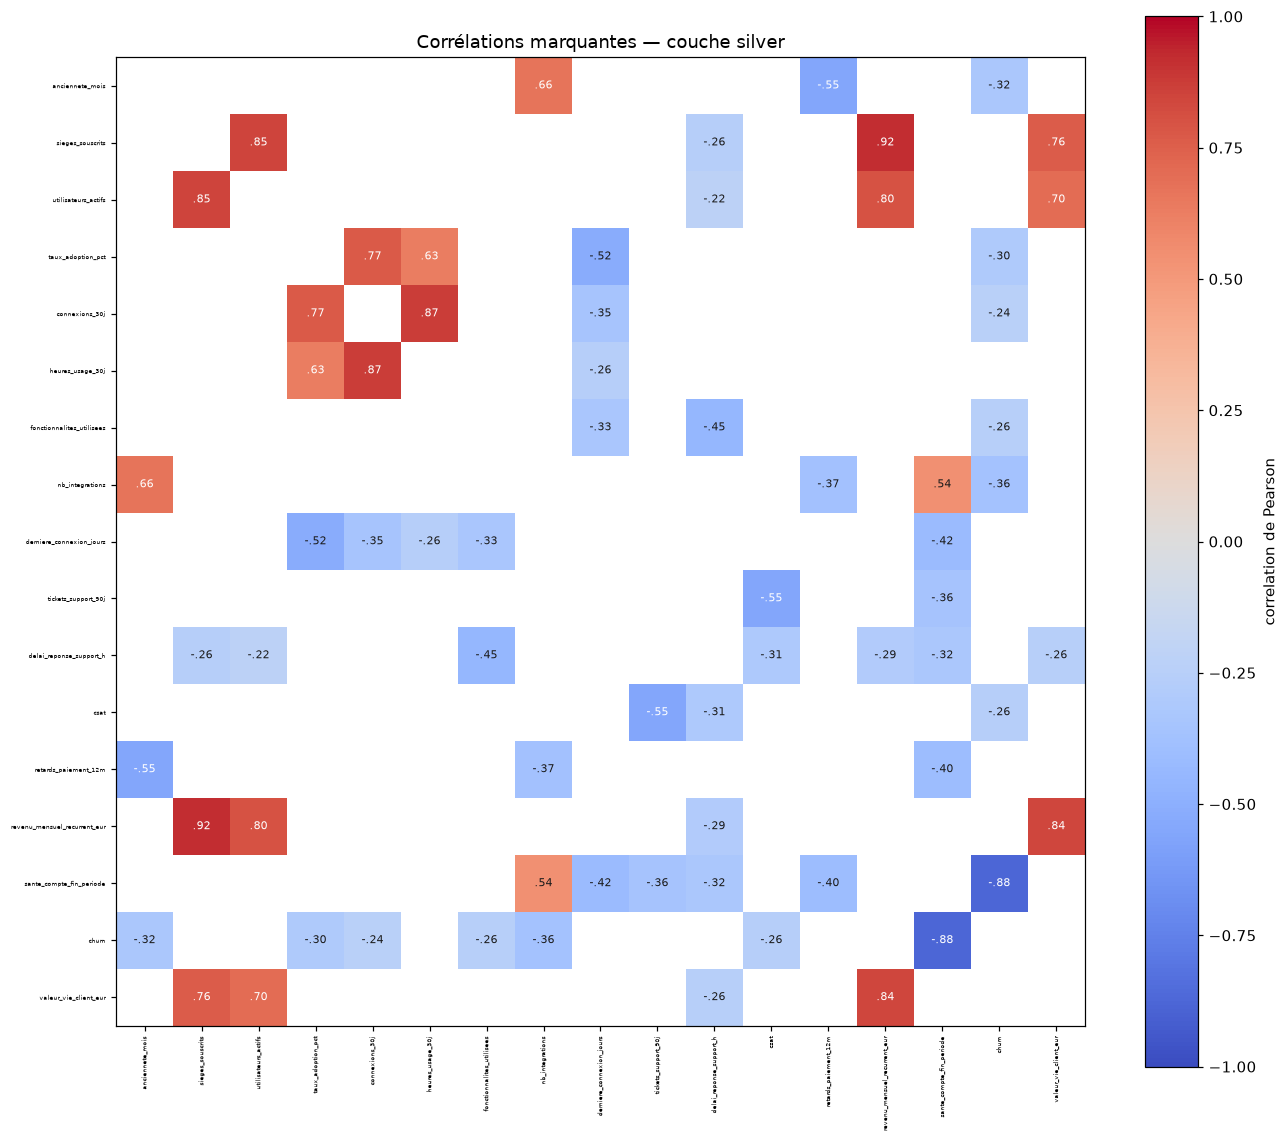

In [9]:
from ml_churn.training.common.correlations import (
    filter_correlations,
    gold_correlations,
    log_correlations,
    silver_correlations,
)
from ml_churn.training.common.explain import display_figure
from ml_churn.training.common.plots import correlation_matrix_figure

CIBLE_REGRESSION = "valeur_vie_client_eur"

# Les figures viennent de la silver : une colonne par variable metier, donc une
# matrice lisible.
matrice_correlations = silver_correlations(CIBLE_REGRESSION)
log_correlations(matrice_correlations, CIBLE_REGRESSION, couche="silver")

# La gold, elle, n'est pas lisible en figure -- 67 colonnes -- mais c'est ce que
# le modele consomme : ses correlations sont donc reportees en log.
log_correlations(gold_correlations(CIBLE_REGRESSION), CIBLE_REGRESSION, couche="gold")

display_figure(
    correlation_matrix_figure(matrice_correlations, titre="Corrélations — couche silver")
)

# Seules les correlations marquantes : au-dessus de 0.5 ou en dessous de -0.2,
# diagonale exclue.
matrice_filtered = filter_correlations(matrice_correlations)

display_figure(
    correlation_matrix_figure(
        matrice_filtered, titre="Corrélations marquantes — couche silver"
    )
)

## 14. Régression — baseline (estimation de la valeur vie client)

Cible du modèle : `valeur_vie_client_eur`.

Le modèle n'utilise que les **dix features** les plus corrélées à la cible,
relevées sur la couche gold à la section précédente.

`churn` est exclue des features candidates, au même titre que
`sante_compte_fin_periode` :
elle est constatée en fin de période, elle ne serait pas disponible au moment
d'estimer la valeur d'un client.

Le découpage est **stratifié sur `churn`** et non sur la cible : une valeur vie
client est quasi unique par client, elle ne peut pas servir à équilibrer les
jeux. Les trois jeux contiennent donc exactement les mêmes clients que pour les
modèles de classification.

`LinearRegression` aux paramètres par défaut — il n'y en a pas à choisir, les
moindres carrés se résolvent sans réglage. Les features sont **standardisées**
en amont : les prédictions n'en dépendent pas, mais les coefficients deviennent
comparables entre eux, là où un coefficient brut classe les features par unité
de mesure. Les moyennes et écarts-types appris sont enregistrés dans le `.json`
du modèle, sous `standardization`.

| Métrique | Lecture |
|---|---|
| `r2` | Part de la variance expliquée, 1 = parfait |
| `mae` | Erreur absolue moyenne, en euros |
| `rmse` | Pénalise les grosses erreurs ; son écart à la MAE mesure le poids des cas extrêmes |
| `mape` | Erreur rapportée à la taille du client, en % |

In [10]:
from ml_churn.training.regression.baseline.regression_baseline_training import (
    train_regression_baseline,
)

resultat_regression = train_regression_baseline()

[DONNEES] : 5000 clients, 10 features
  retenues : revenu_mensuel_recurrent_eur, sieges_souscrits, utilisateurs_actifs, taille_entreprise_ge, plan_ent, fonctionnalites_utilisees, delai_reponse_support_h, taille_entreprise_tpe, plan_str, taille_entreprise_pme
  train 3000 / validation 1000 / test 1000
  cible sur le test : mediane 11,210 €, moyenne 71,787 €, max 2,000,000 €

[PERFORMANCE] sur le jeu de test
  r2                            0.67   part de la variance expliquee, 1 = parfait
  mae                       37640.96   erreur absolue moyenne, en euros
  rmse                     110900.89   racine de l'erreur quadratique moyenne, en euros
  mape                        184.37   erreur absolue moyenne rapportee a la valeur reelle, en %

[MODELE ENREGISTRE] artifacts/regression/baseline/2026-09-26/regression_baseline.joblib


## 15. Régression — recherche des hyperparamètres (XGBoost)

Même espace de recherche que côté classification : neuf hyperparamètres,
`TPESampler`, un modèle réentraîné par essai, les hyperparamètres choisis sur la
validation et le test réservé à la mesure finale.

**L'objectif par défaut est la MAE, pas le R².** Le R² dérive de l'erreur au
carré, dominée par les quelques comptes à plusieurs centaines de milliers
d'euros : l'optimiser revient à soigner les gros clients et à abandonner les
autres. La MAE traite chaque euro d'erreur à égalité. `r2`, `rmse` et `mape`
restent disponibles via le paramètre `objectif`.

In [11]:
from ml_churn.training.regression.final.regression_xgboost_tuning import (
    tune_regression_xgboost,
)

resultat_tuning_regression = tune_regression_xgboost(n_essais=30)

[RECHERCHE] hyperparametres XGBoost, 30 essais
  train 3000 / validation 1000 / test 1000  (64 features)

[OBJECTIF] mae a minimize

    essai      r2         mae         rmse     mape
     1/30    0.64      41,805      124,346     167%  <- meilleur
     2/30    0.67      43,583      120,037     290%
     3/30    0.69      38,871      116,433     162%  <- meilleur
     4/30    0.69      38,031      116,087     128%  <- meilleur
     5/30    0.68      40,946      118,505     212%
     6/30    0.68      40,486      117,215     193%
     7/30    0.70      38,152      114,700     134%
     8/30    0.69      37,824      115,710     165%  <- meilleur
     9/30    0.67      38,642      120,036      98%
    10/30    0.69      38,342      114,985     180%
    11/30    0.67      39,500      119,541     124%
    12/30    0.68      38,702      117,730     135%
    13/30    0.67      39,283      118,936     125%
    14/30    0.67      42,662      119,540     173%
    15/30    0.70      37,345      

2026/09/26 19:03:08 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/avallet/machine-learning/ml-churn
/Users/avallet/machine-learning/ml-churn/.venv/lib/python3.13/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/09/26 19:03:08 INFO mlflow.utils.uv_utils: Detected uv projec


[HYPERPARAMETRES RETENUS] mae = 37,345.03 en validation
  n_estimators         250
  max_depth            6
  learning_rate        0.02
  subsample            0.60
  colsample_bytree     1.00
  min_child_weight     6
  gamma                4.91
  reg_alpha            7.73
  reg_lambda           0.03

[PERFORMANCE] sur le jeu de test
  r2                            0.65
  mae                      36,651.05
  rmse                    113,404.17
  mape                        148.70

[MEILLEURS ESSAIS] les 5 premiers
    essai      r2         mae         rmse     mape
       15    0.70      37,345      114,427     152%
       30    0.69      37,352      115,327     110%
       17    0.71      37,388      111,609     131%
       28    0.69      37,420      116,402     129%
       27    0.69      37,533      116,142     161%

  runs enregistres dans /Users/avallet/machine-learning/ml-churn/mlflow.db (uv run mlflow ui)

[EMPREINTE CARBONE] de la recherche complete
  ⏱️  duree             10.9

## 16. Régression — XGBoost

Mêmes données que la section précédente : même cible, même découpage, mêmes dix
features. Seul change ce qui apprend — des arbres au lieu d'une combinaison
linéaire.

Deux conséquences sur une cible aussi étalée. Les arbres ne peuvent pas prédire
hors de l'intervalle vu à l'entraînement, donc **aucune valeur négative**, là où
le modèle linéaire en produit 8 %. Et ils captent les effets de seuil qu'une
droite ne représente pas.

Pas de standardisation ici : un arbre découpe sur des seuils, l'échelle des
features lui est indifférente. Les hyperparamètres sont volontairement
prudents — arbres peu profonds, apprentissage lent — les réglages par défaut de
XGBoost surapprenant les quelques comptes à plusieurs centaines de milliers
d'euros.

In [12]:
from ml_churn.training.regression.final.regression_xgboost_training import (
    train_regression_xgboost,
)

resultat_regression_xgboost = train_regression_xgboost(
    hyperparametres=resultat_tuning_regression.hyperparametres,
)

[DONNEES] : 5000 clients, 64 features
  train 3000 / validation 1000 / test 1000
  cible sur le test : mediane 11,210 €, moyenne 71,787 €, max 2,000,000 €

[PERFORMANCE] sur le jeu de test
  r2                            0.65   part de la variance expliquee, 1 = parfait
  mae                       36651.05   erreur absolue moyenne, en euros
  rmse                     113404.17   racine de l'erreur quadratique moyenne, en euros
  mape                        148.70   erreur absolue moyenne rapportee a la valeur reelle, en %

[MODELE ENREGISTRE] artifacts/regression/final/2026-09-26/regression_xgboost.joblib
